# Mental Health in Tech Survey

The data used herein was sourced from:<br>
https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey/data

The `mhit` project is composed of 4 notebooks:<br>**A. Data transformations**<br> 
Because the data is unwieldy in its original form, before it was used for analysis and insights, I transformed it as follows:<br> 1. Created a unique id for each survey respondent (`rid`) and mapped all responses to this id;<br>2. Mapped all survey questions to their unique identifiers (`Q1`-`Q63`) and used the question identifiers as compact column headers.<br>3. Structured responses referencing conditions by first mapping all conditions to their own unique identifier (`C1` - `C51`) and then mapping each respondent to all of the conditions they listed as one they either currently have or one they have been diagnosed with.<br>4. Similarly, mapped all job positions to unique identifiers (`P1`-`P15`) and all respondents to each position they listed as part of their current responsibilities.<br>5. Finally, the responses are captured as text and while most represent ordinal or quantifiable information, further analysis required mapping of the text to numeric values *(e.g. "Yes" = 1 / "No" = 0 or "Yes, all" = 1, "Some of them" = 0.5, "No, none" = 0)*<br>
**B. EDA and additional data cleaning**<br>**C. Analysis and hypothesis testing**<br>**D. NLP and Sentiment Analysis (THIS NOTEBOOK)**<br>

### Library imports, notebook settings, and data files

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors 
from mpl_toolkits.mplot3d import axes3d
import seaborn as sns
from collections import Counter

from cycler import cycler

import nltk
from nltk import tokenize
from nltk.sentiment import SentimentAnalyzer
from nltk.sentiment.util import *
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.stem import porter
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords
nltk.download("punkt")
nltk.download("stopwords")

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation

import networkx as nx

[nltk_data] Downloading package punkt to /Users/martalew/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/martalew/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
mhit_cmap = mcolors.LinearSegmentedColormap.from_list('mhit', ['lightgray', 'steelblue'])
custom_cycler = cycler(color=[mhit_cmap(i) for i in np.linspace(0, 1, 10)][::-1])
plt.rc('axes', prop_cycle=custom_cycler)
plt.rcParams['figure.figsize'] = (5,4)
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
plt.rcParams['figure.titlesize'] = 8
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['grid.color'] = 'lightgray'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['figure.labelsize'] = 7
pd.set_option('display.max_columns', None)

%config InlineBackend.figure_format = 'retina'

In [3]:
mhit = pd.read_csv('data/mental-heath-in-tech-2016_20161114.csv', index_col='rid')
conditions_map = pd.read_csv('data/all_condition_ids.csv', index_col = 'cid')
diagnosed_conditions = pd.read_csv('data/diagnosed_conditions_w_ids.csv', index_col = 'rid')
current_conditions = pd.read_csv('data/current_conditions_w_ids.csv', index_col = 'rid')
demo = demo = pd.read_csv('data/demographics_w_ids.csv', index_col = 'rid')
responses = pd.read_csv('data/responses_w_ids.csv', index_col = 'rid')
mhit_question_ids = pd.read_csv('data/all_question_ids.csv')
mhit_question_ids = {q:i for q, i in zip(mhit_question_ids['question'], mhit_question_ids['qid'])}
mhit_question_ids_rev = {i: q for q, i in mhit_question_ids.items()}

### Natural Language Methods (free-form text analysis)

In [7]:
for q in [f'Q{i}' for i in range(37, 41)]:
    print(q, mhit_question_ids_rev[q])

Q37 Would you be willing to bring up a physical health issue with a potential employer in an interview?
Q38 Why or why not?
Q39 Would you bring up a mental health issue with a potential employer in an interview?
Q40 Why or why not?.1


#### 1. Phrases used to explain willingness to mention physical / mental health issues in interviews

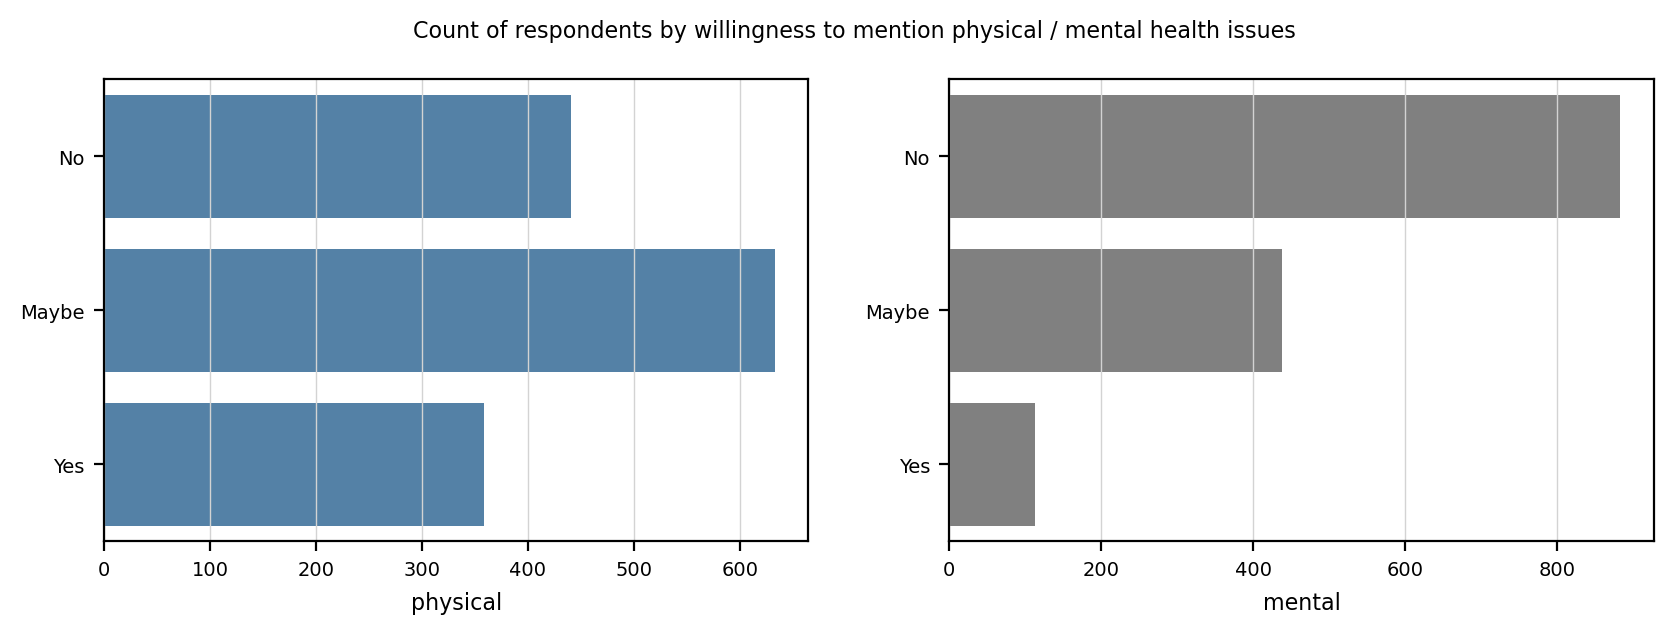

In [8]:
fig, axs = plt.subplots(1,2, figsize = (10,3))
plt.suptitle(f"Count of respondents by willingness to mention physical / mental health issues")
questions = ['Q37', 'Q39']
labels = ['physical', 'mental']
colors = ['steelblue', 'gray']
for i in range(2):
    sns.countplot(responses, y = questions[i], ax = axs[i], color = colors[i], order = [0,0.5, 1])
    axs[i].grid(axis = 'x', which = 'major')
    axs[i].set_yticks(range(3), ['No', 'Maybe', 'Yes'])
    axs[i].set_ylabel('');    
    axs[i].set_xlabel(labels[i]);

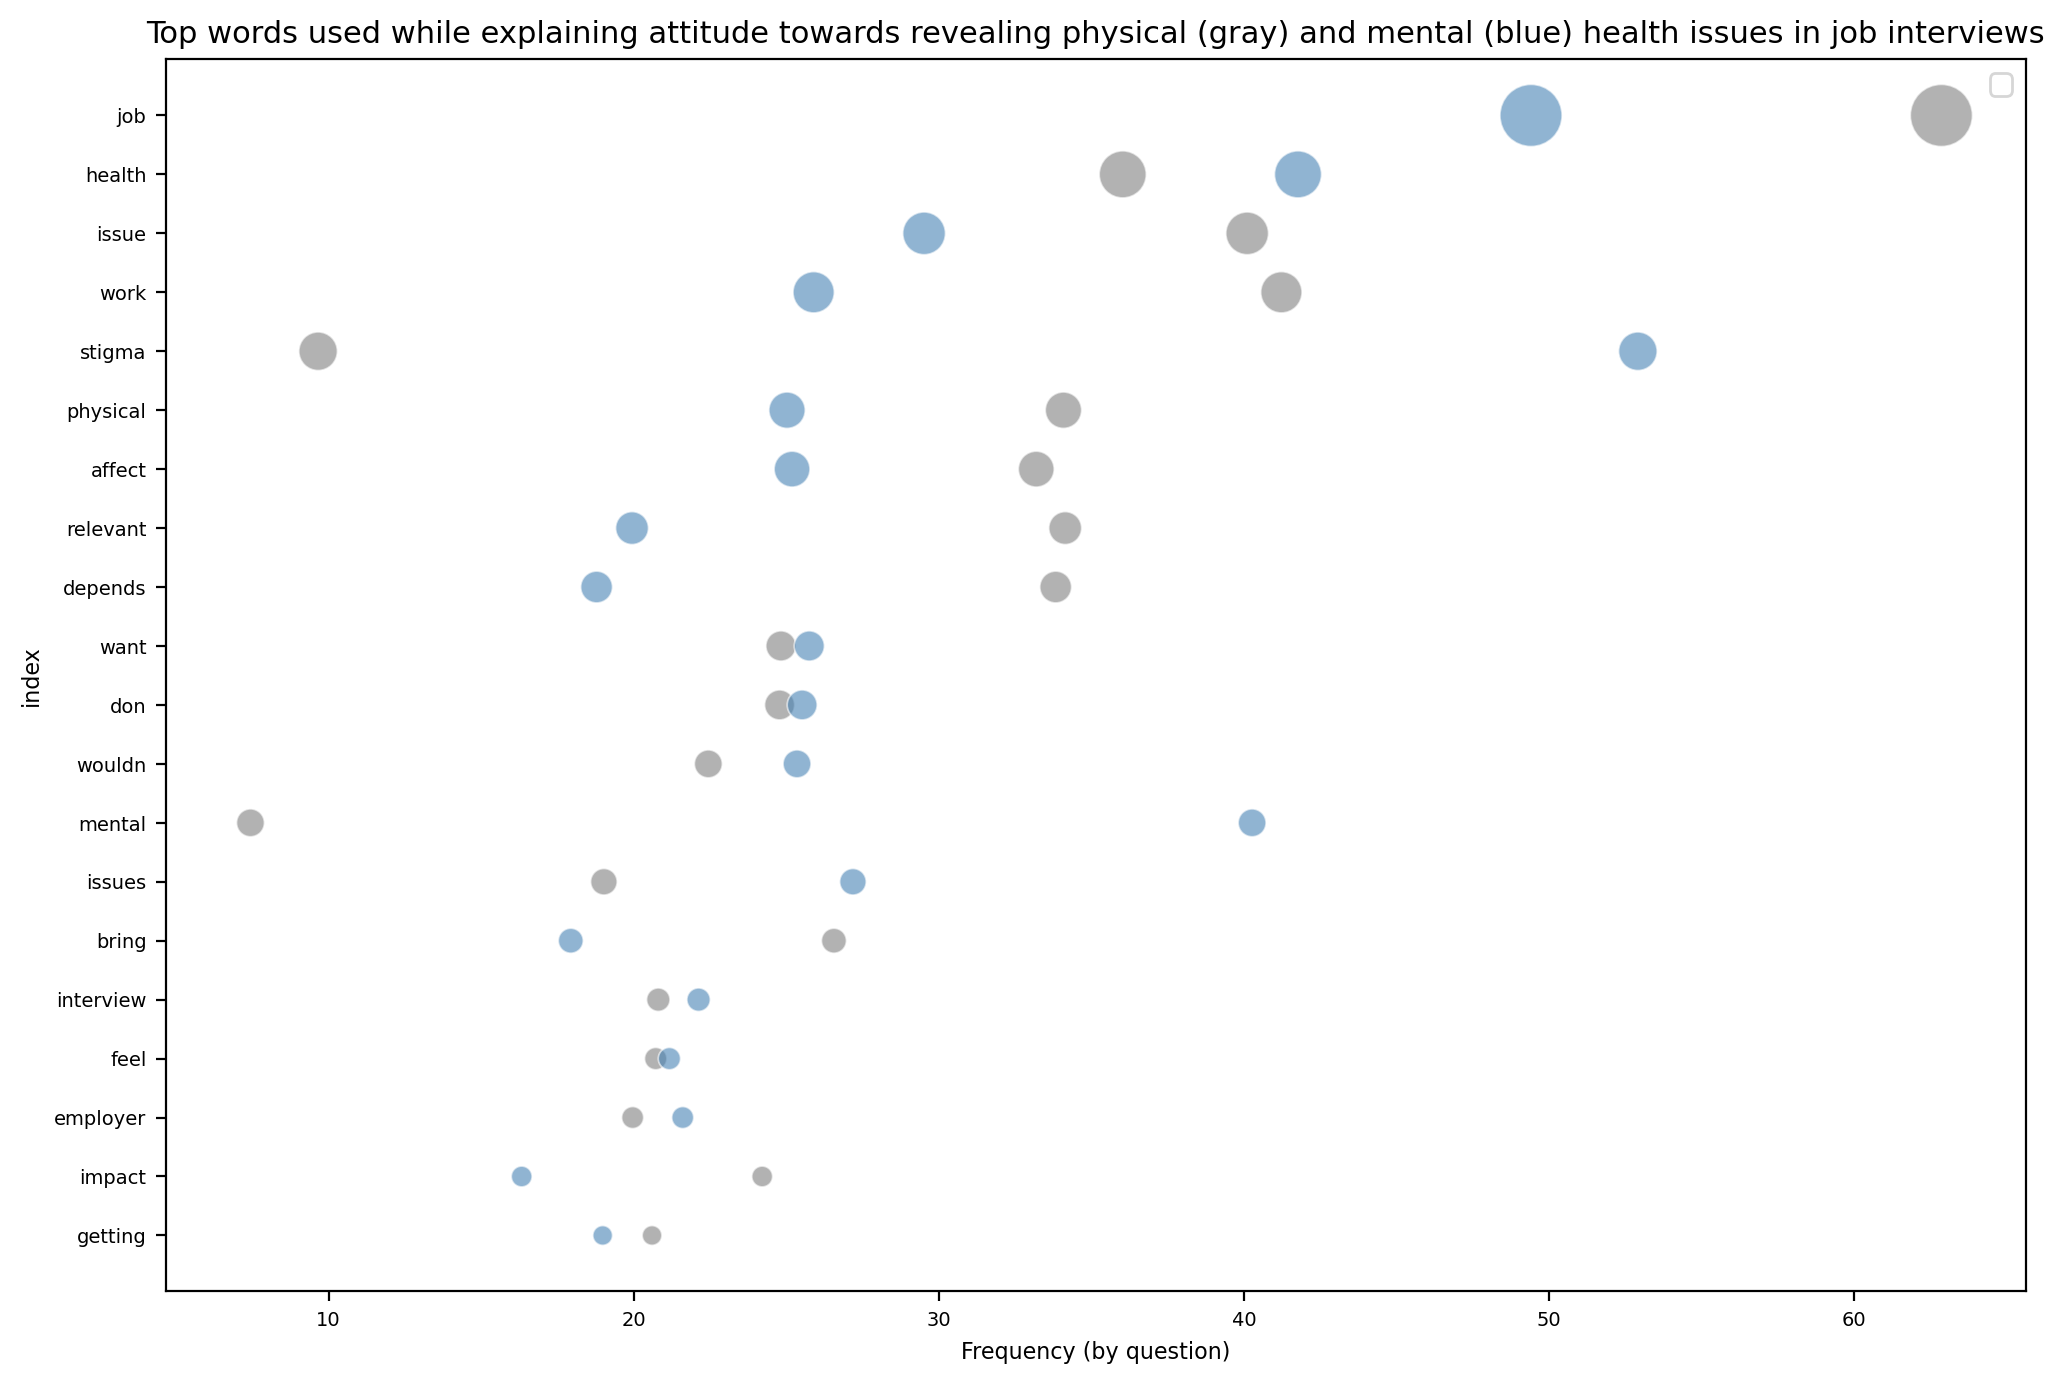

In [9]:
cv = TfidfVectorizer(stop_words='english')
cv.fit(responses['Q38'].fillna('').to_list())

X = cv.transform(responses['Q38'].fillna(''))

q38uni = pd.DataFrame(data = X.toarray(), index = responses.index,
                  columns = cv.get_feature_names_out())

cv = TfidfVectorizer(stop_words='english')
cv.fit(responses['Q40'].fillna('').to_list())

X = cv.transform(responses['Q40'].fillna(''))

q40uni = pd.DataFrame(data = X.toarray(), index = responses.index,
                  columns = cv.get_feature_names_out())

count_comp = q38uni.sum().reset_index().merge(q40uni.sum().reset_index(), 
                                          left_on = 'index', right_on = 'index').set_index('index').rename({'0_x': 'Q38', 
                                                                                                            '0_y': 'Q40'}, axis = 1)
count_comp['total'] = count_comp.T.sum()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=count_comp.reset_index().sort_values('total', ascending = False).head(20), x='Q38', y='index', 
                size='total', sizes=(50, 500), color='gray', alpha=0.6, )
sns.scatterplot(data=count_comp.reset_index().sort_values('total', ascending = False).head(20), x='Q40', y='index', 
                size='total', sizes=(50, 500), color='steelblue', alpha=0.6)
plt.xlabel("Frequency (by question)")
plt.title("Top words used while explaining attitude towards revealing physical (gray) and mental (blue) health issues in job interviews",
         fontsize = 11)
plt.legend('')
plt.show()

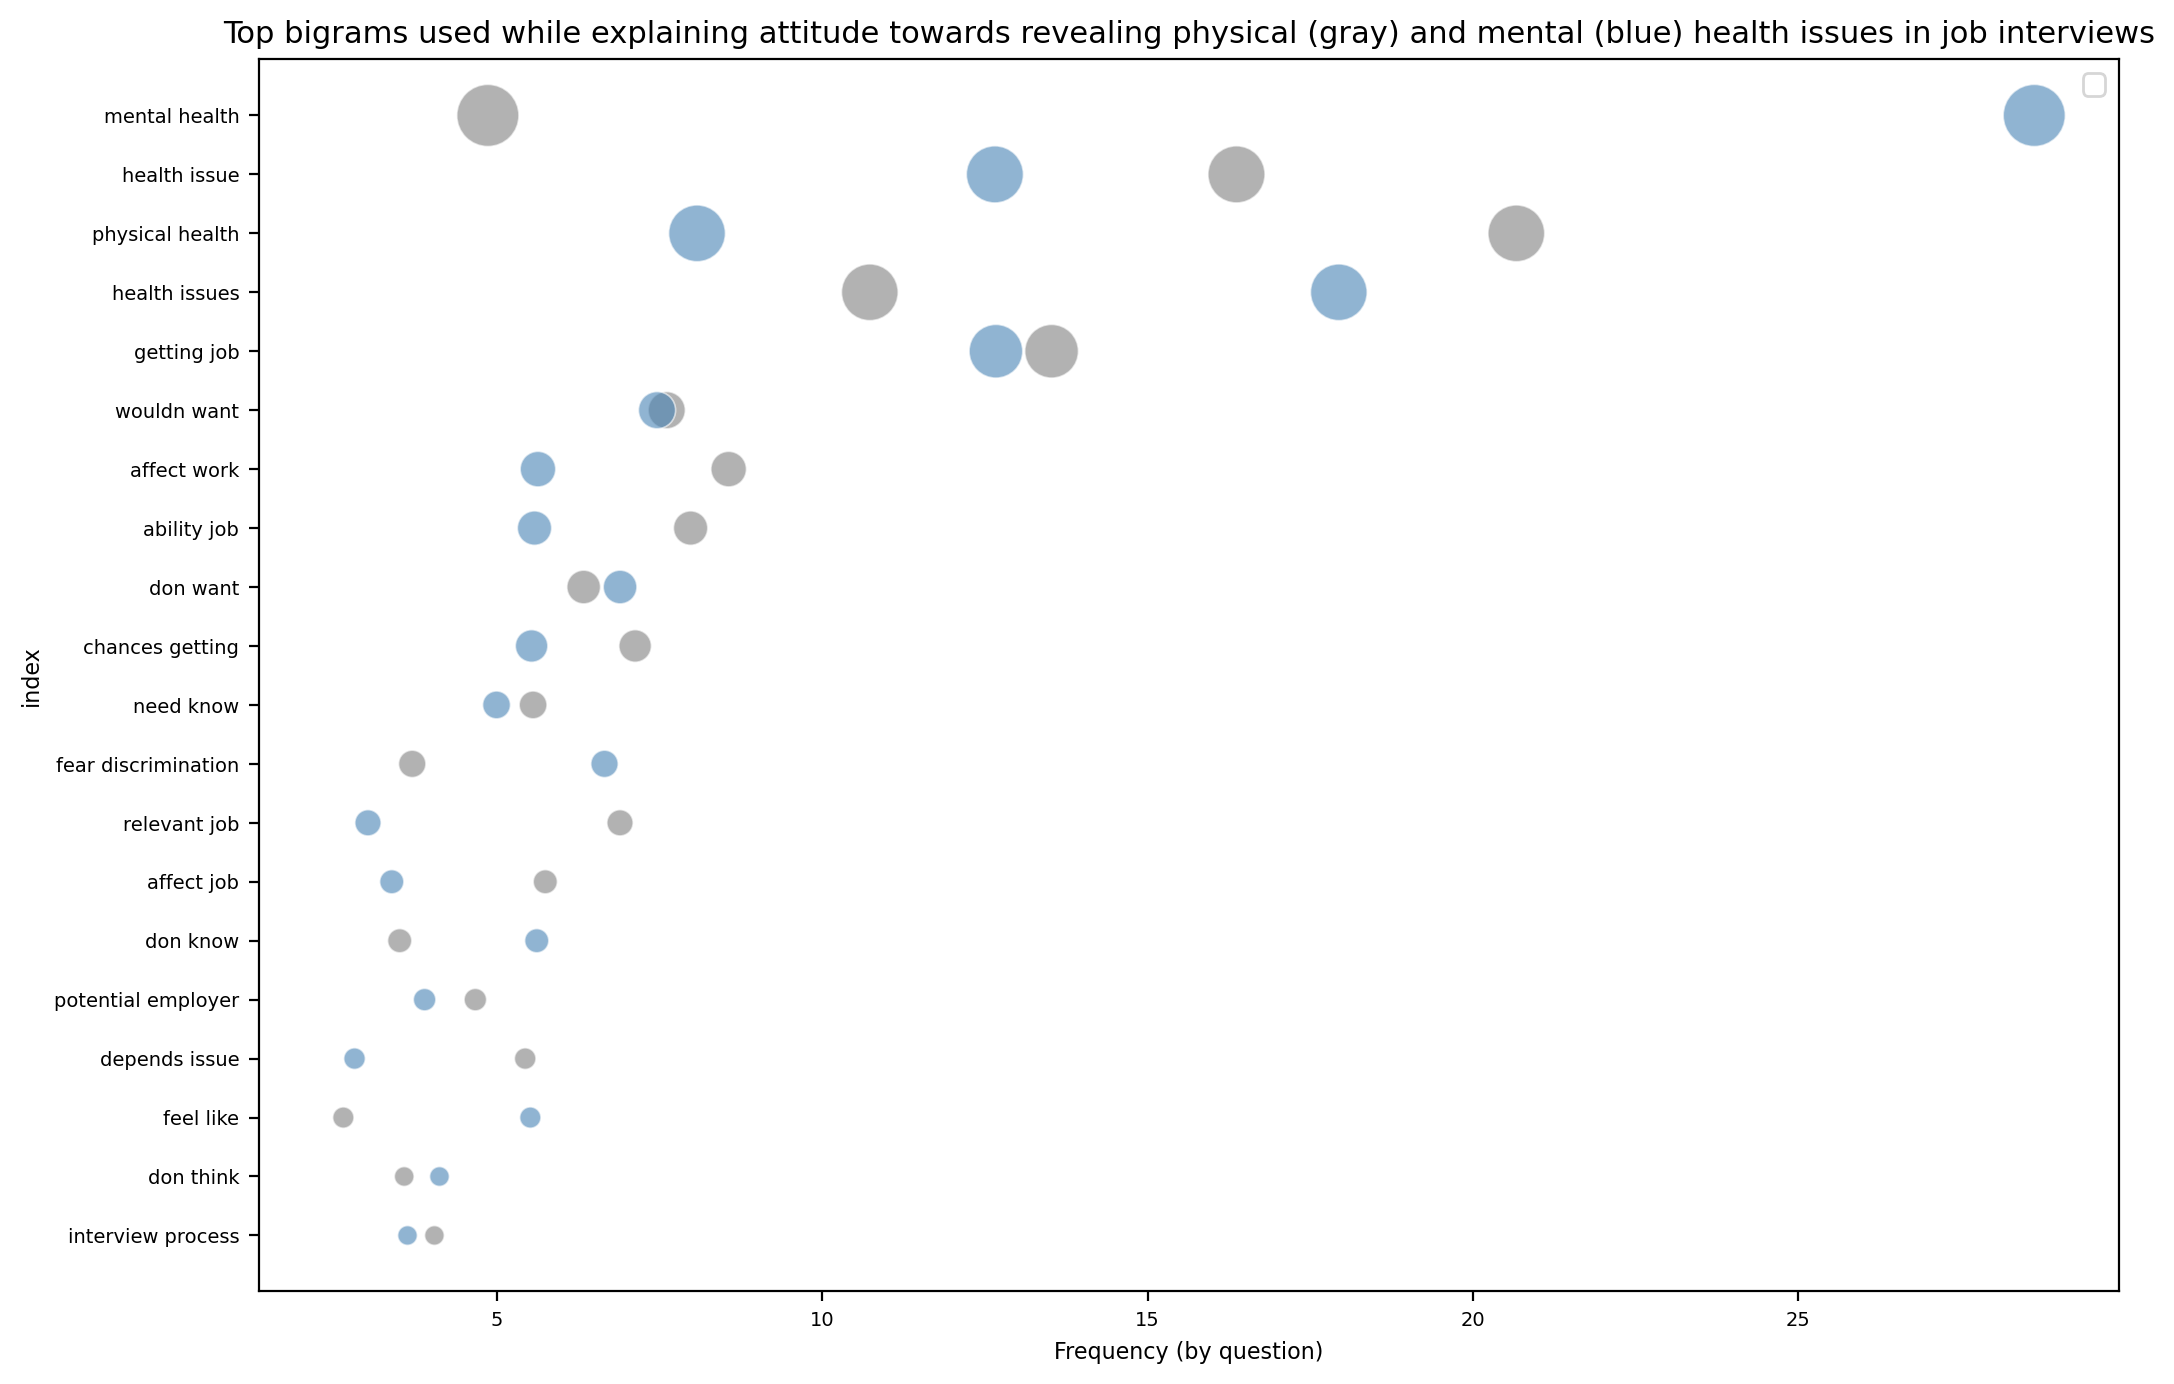

In [10]:
cv = TfidfVectorizer(stop_words='english', ngram_range=(2,2))
cv.fit(responses['Q38'].fillna('').to_list())

X = cv.transform(responses['Q38'].fillna(''))

q38bi = pd.DataFrame(data = X.toarray(), index = responses.index,
                  columns = cv.get_feature_names_out())

cv = TfidfVectorizer(stop_words='english', ngram_range = (2,2))
cv.fit(responses['Q40'].fillna('').to_list())

X = cv.transform(responses['Q40'].fillna(''))

q40bi = pd.DataFrame(data = X.toarray(), index = responses.index,
                  columns = cv.get_feature_names_out())

count_comp = q38bi.sum().reset_index().merge(q40bi.sum().reset_index(), 
                                          left_on = 'index', right_on = 'index').set_index('index').rename({'0_x': 'Q38', 
                                                                                                            '0_y': 'Q40'}, axis = 1)
count_comp['total'] = count_comp.T.sum()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=count_comp.reset_index().sort_values('total', ascending = False).head(20), x='Q38', y='index', 
                size='total', sizes=(50, 500), color='gray', alpha=0.6, )
sns.scatterplot(data=count_comp.reset_index().sort_values('total', ascending = False).head(20), x='Q40', y='index', 
                size='total', sizes=(50, 500), color='steelblue', alpha=0.6)
plt.xlabel("Frequency (by question)")
plt.title("Top bigrams used while explaining attitude towards revealing physical (gray) and mental (blue) health issues in job interviews",
         fontsize = 11)
plt.legend('')
plt.show()

In [11]:
cv = TfidfVectorizer(stop_words='english', ngram_range=(2,2))
cv.fit(responses['Q38'].fillna('').to_list())

X = cv.transform(responses['Q38'].fillna(''))
q38bi = pd.DataFrame(data = X.toarray(), index = responses.index,
                  columns = cv.get_feature_names_out())

cv = TfidfVectorizer(stop_words='english', ngram_range = (2,2))
cv.fit(responses['Q40'].fillna('').to_list())
X = cv.transform(responses['Q40'].fillna(''))

q40bi = pd.DataFrame(data = X.toarray(), index = responses.index,
                  columns = cv.get_feature_names_out())

In [12]:
count_comp['Q38y'] = [q38bi.loc[responses[responses['Q37']==1].index, x].sum() if x in q38bi.columns else 0 for x in count_comp.index]
count_comp['Q38n'] = [q38bi.loc[responses[responses['Q37']==0].index, x].sum() if x in q38bi.columns else 0  for x in count_comp.index]
count_comp['Q40y'] = [q40bi.loc[responses[responses['Q39']==1].index, x].sum() if x in q40bi.columns else 0 for x in count_comp.index]
count_comp['Q40n'] = [q40bi.loc[responses[responses['Q39']==0].index, x].sum() if x in q40bi.columns else 0 for x in count_comp.index]

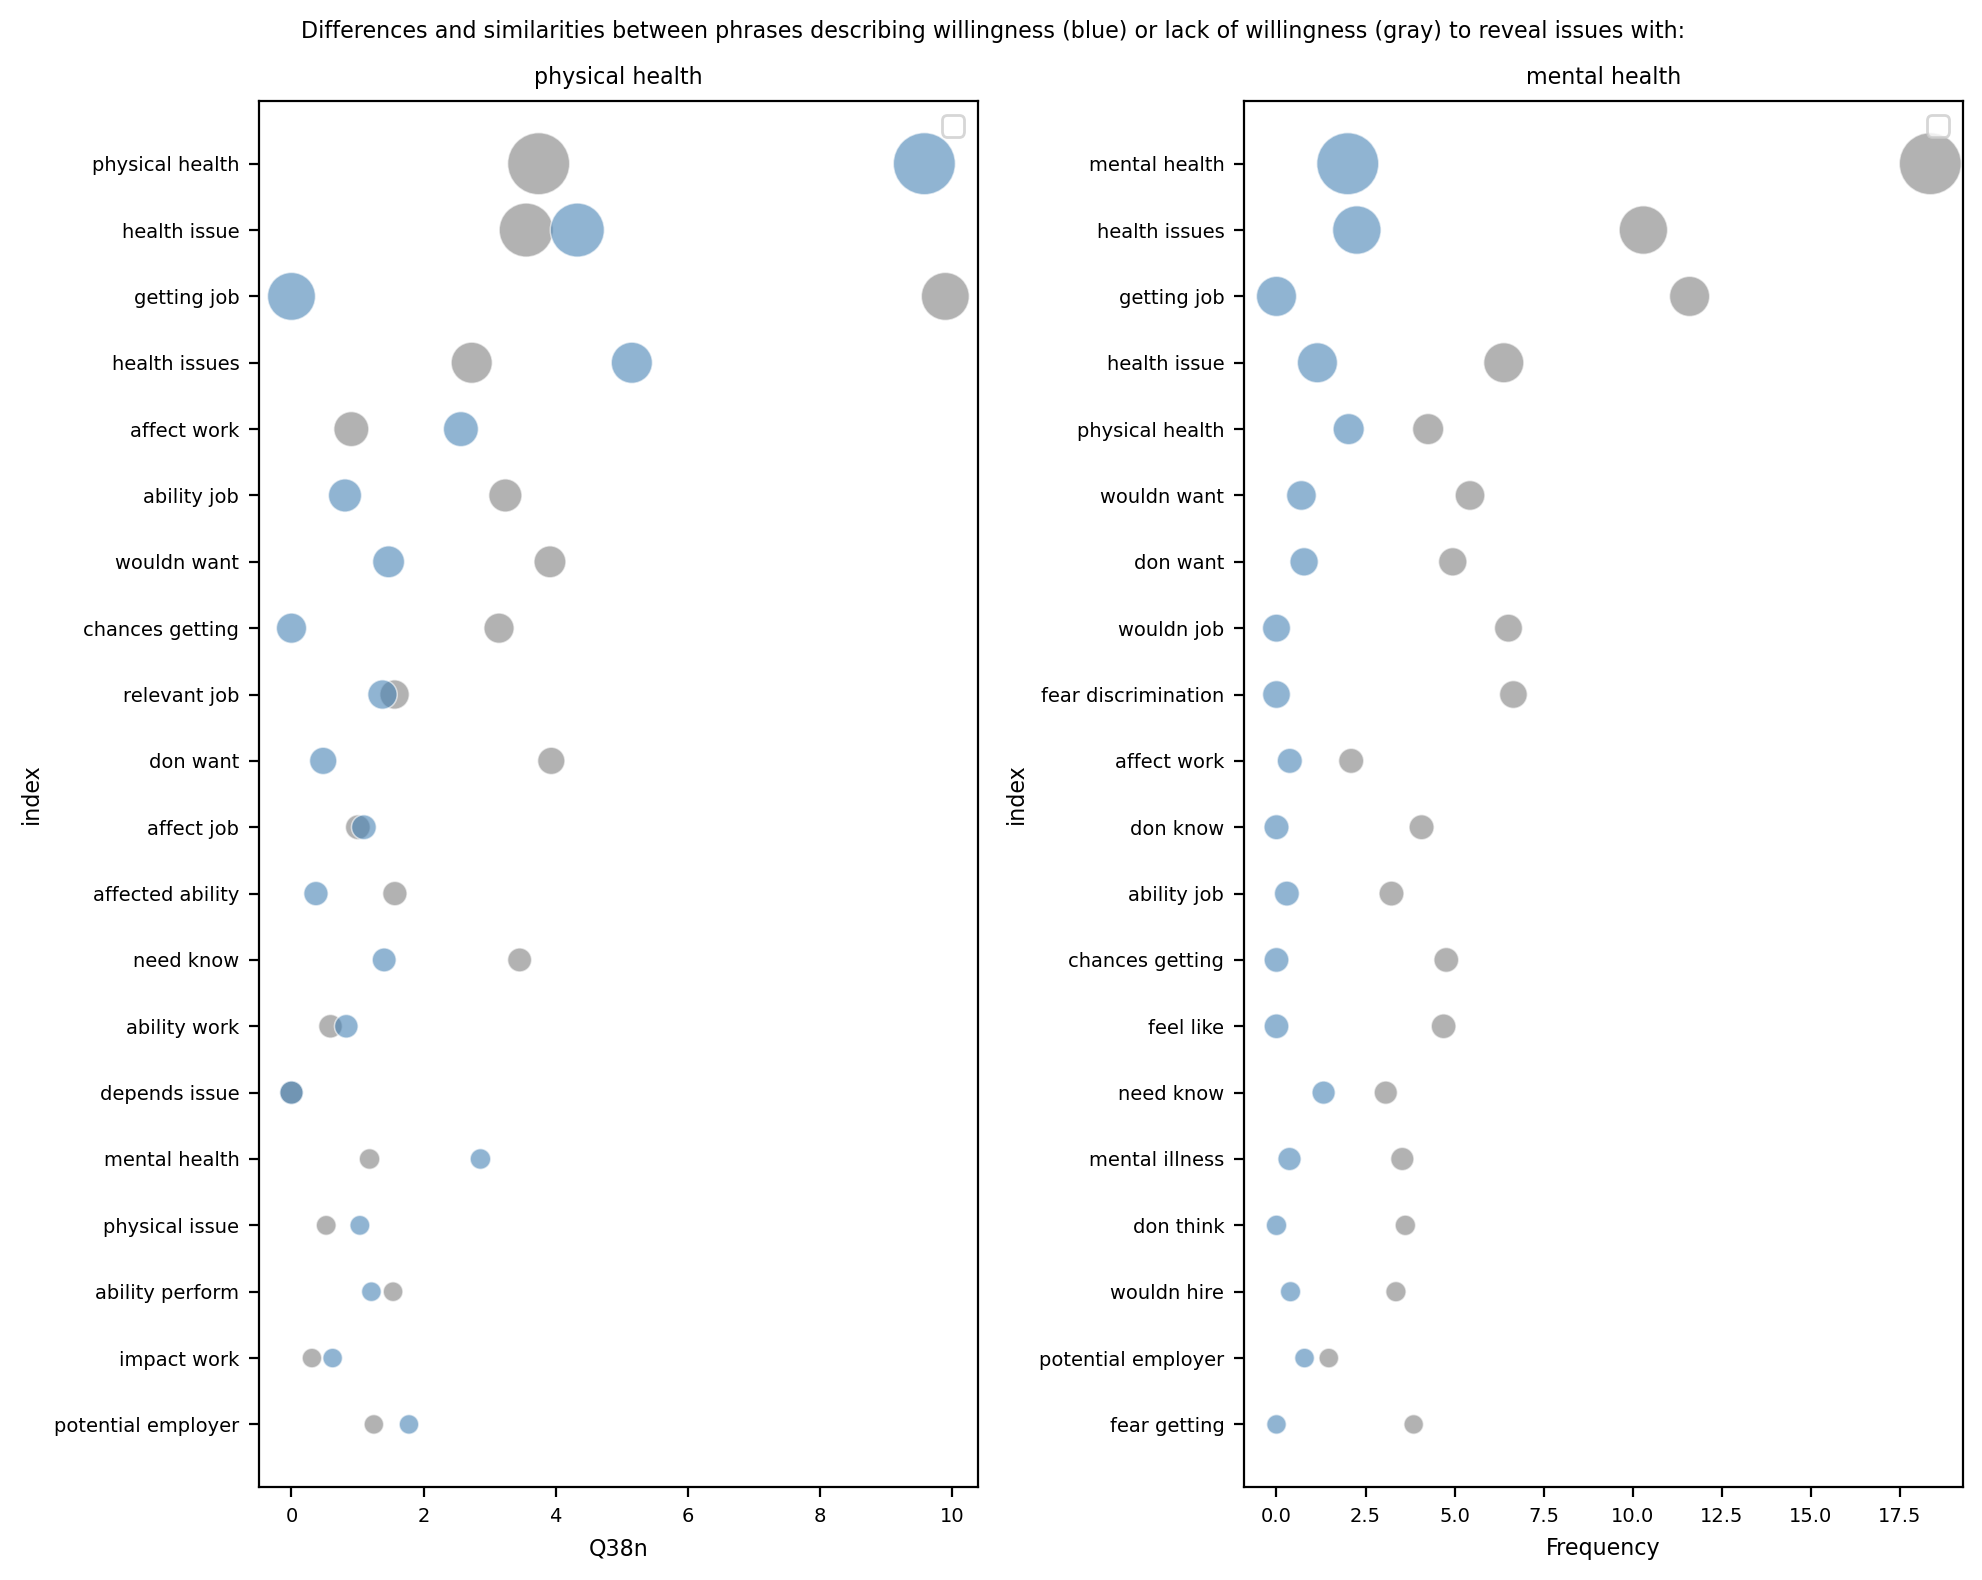

In [13]:
fig, axs = plt.subplots(1,2, figsize=(10, 8))
plt.suptitle("Differences and similarities between phrases describing willingness (blue) or lack of willingness (gray) to reveal issues with:")
for i in range(2):
    for j in range(2):
        sns.scatterplot(data=count_comp.reset_index().sort_values(f'Q{38+2*i}', ascending = False).head(20), x=f'Q{38+2*i}{['n', 'y'][j]}',
                        y='index', size=f'Q{38+2*i}', sizes=(50, 500), color=['gray', 'steelblue'][j], alpha=0.6, ax = axs[i])
        # sns.scatterplot(data=count_comp.reset_index().sort_values('total', ascending = False).head(20), x=f'Q{38+2*i}y' y='index', 
        #                 size='total', sizes=(50, 500), color='steelblue', alpha=0.6, legend = 'yes', ax = axs[i]
        plt.xlabel("Frequency")
        axs[i].set_title(f"{['physical', 'mental'][i]} health")
        axs[i].legend('')
plt.tight_layout()
plt.show()

#### 2. Word co-occurrences

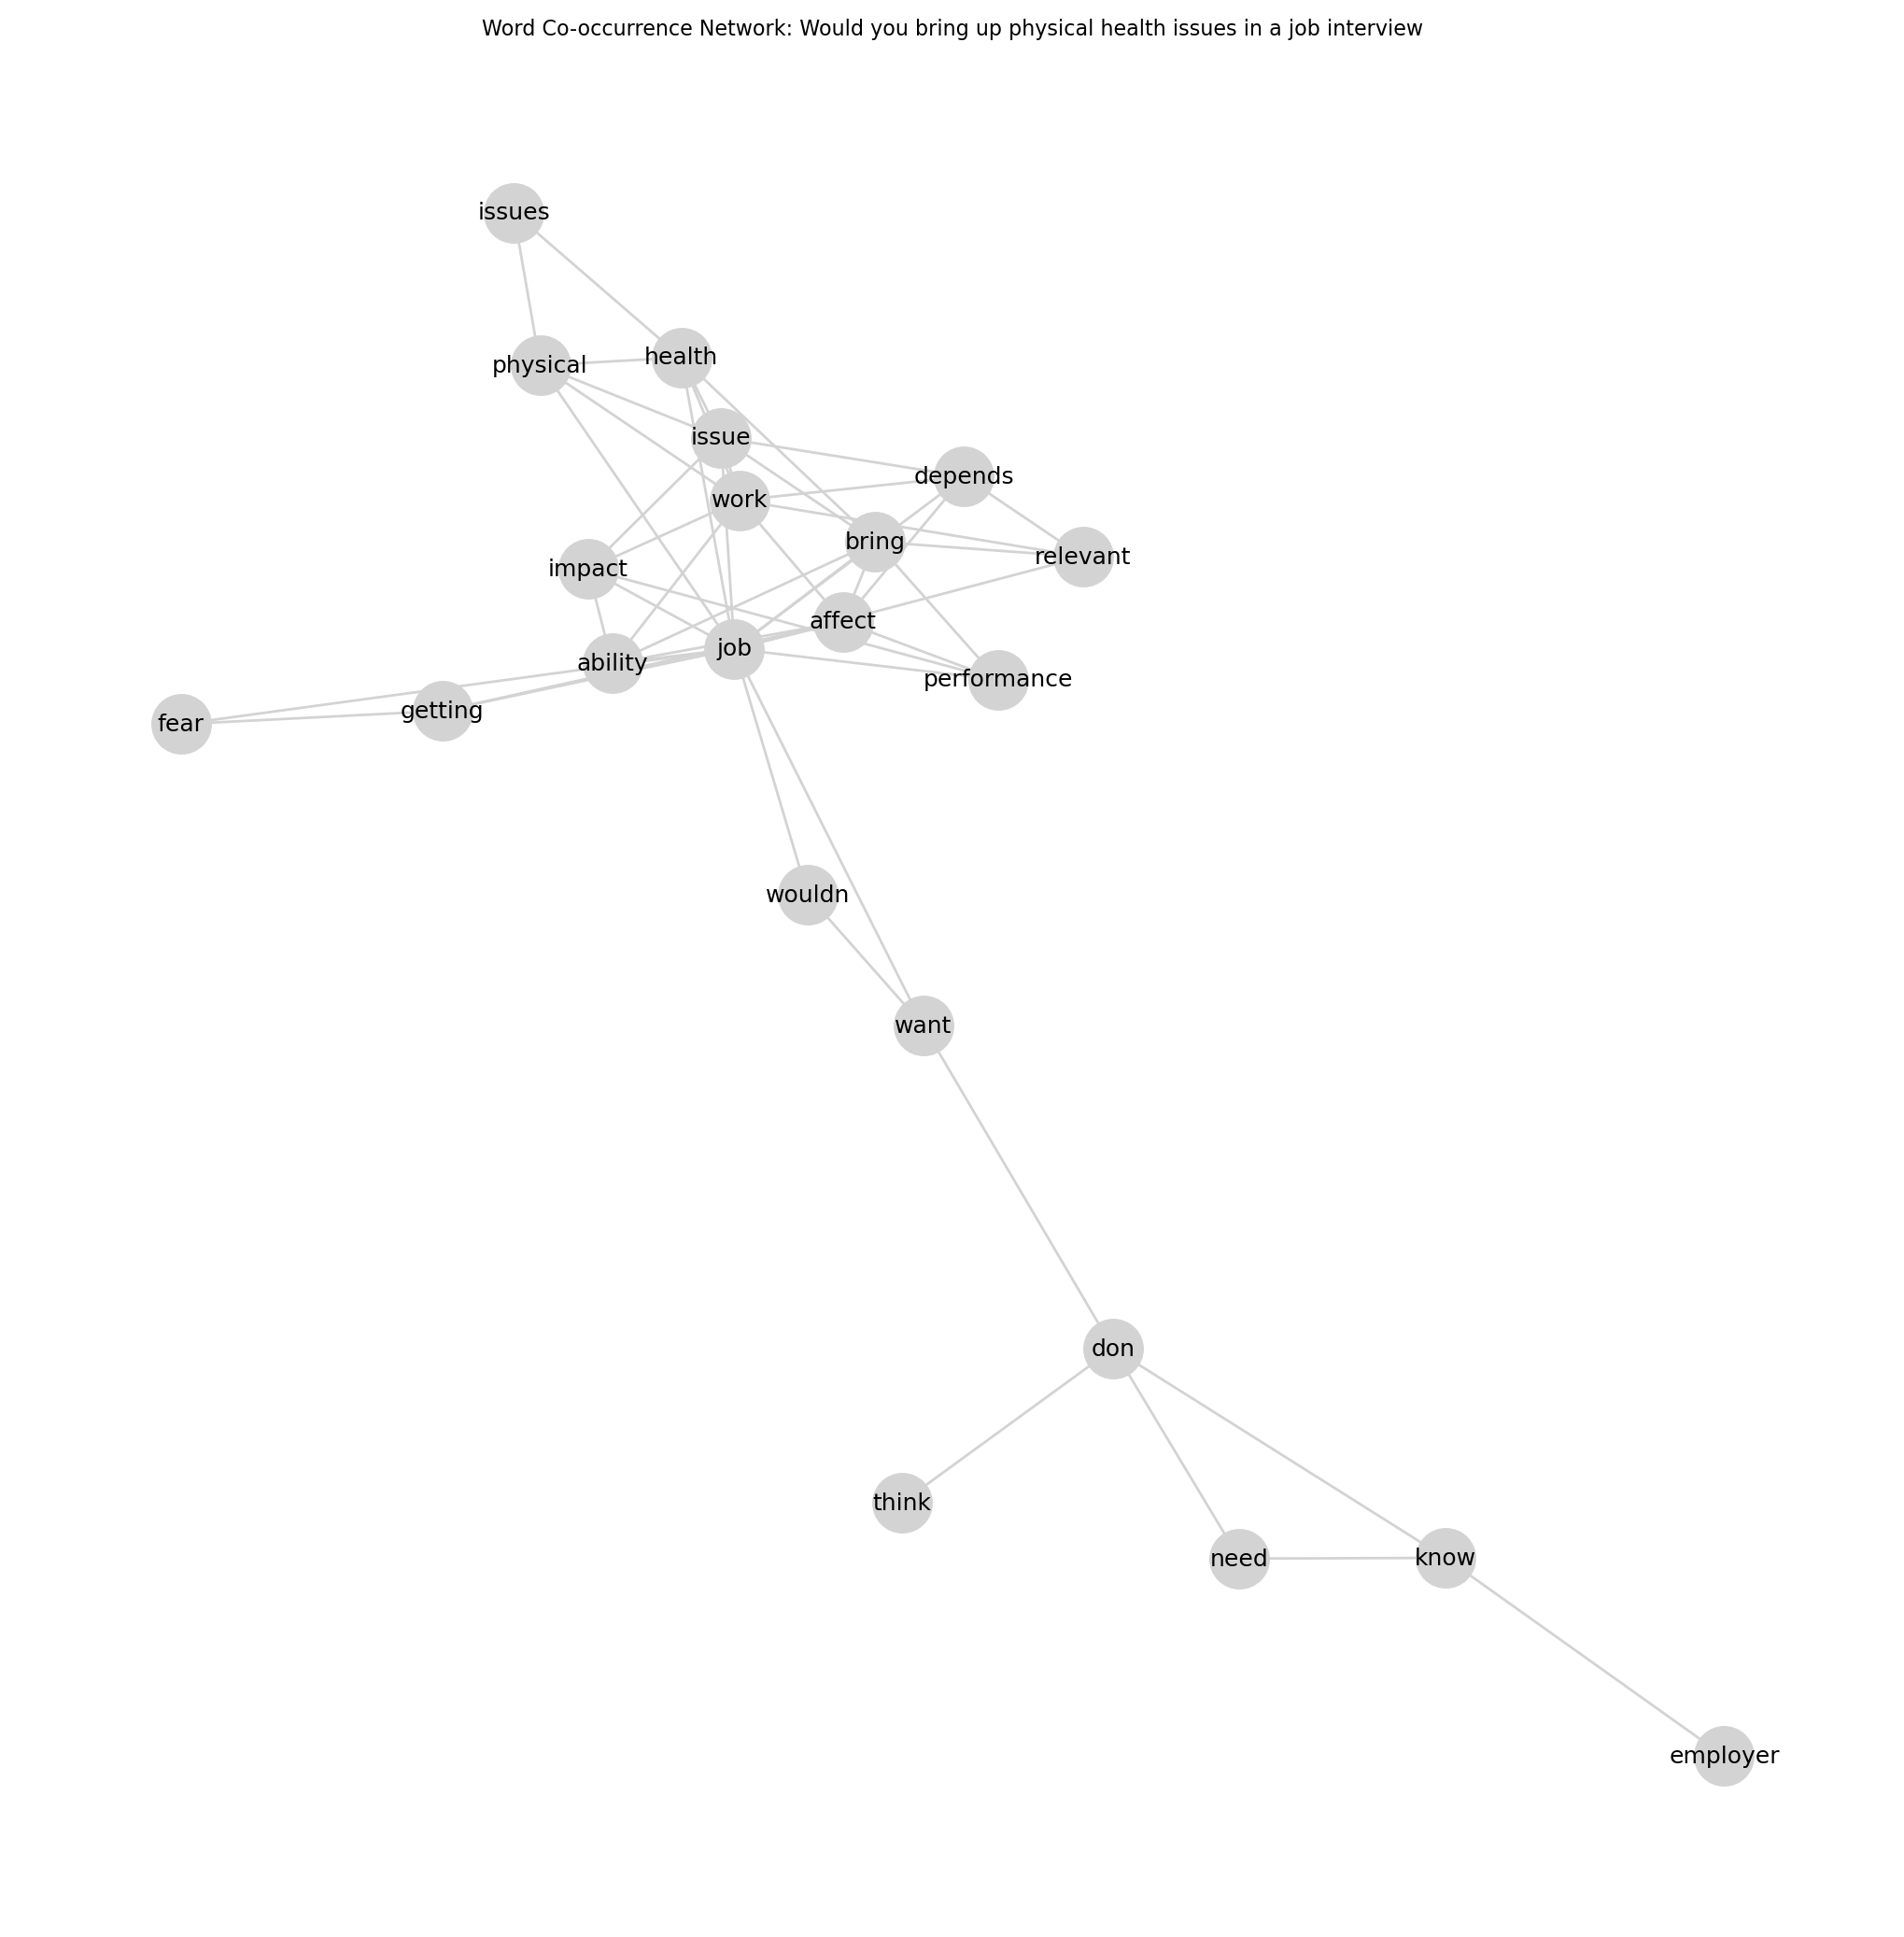

In [14]:
q38uni_cm = (q38uni[q38uni.iloc[:,:-1].sum().sort_values(ascending = False).head(25).index].T @ 
                       q38uni[q38uni.iloc[:,:-1].sum().sort_values(ascending = False).head(25).index])

G = nx.Graph()
for word1, word2 in q38uni_cm.stack().index:
    if word1 != word2 and q38uni_cm.loc[word1, word2] > np.quantile(np.array(q38uni_cm).flatten(), 0.8):  # Adjust threshold
        G.add_edge(word1, word2, weight=q38uni_cm.loc[word1, word2])

plt.figure(figsize=(10, 10))
nx.draw(G, with_labels=True, node_size=500, node_color = 'lightgray', edge_color='lightgray', font_size=9)
plt.title("Word Co-occurrence Network: Would you bring up physical health issues in a job interview")
plt.show()

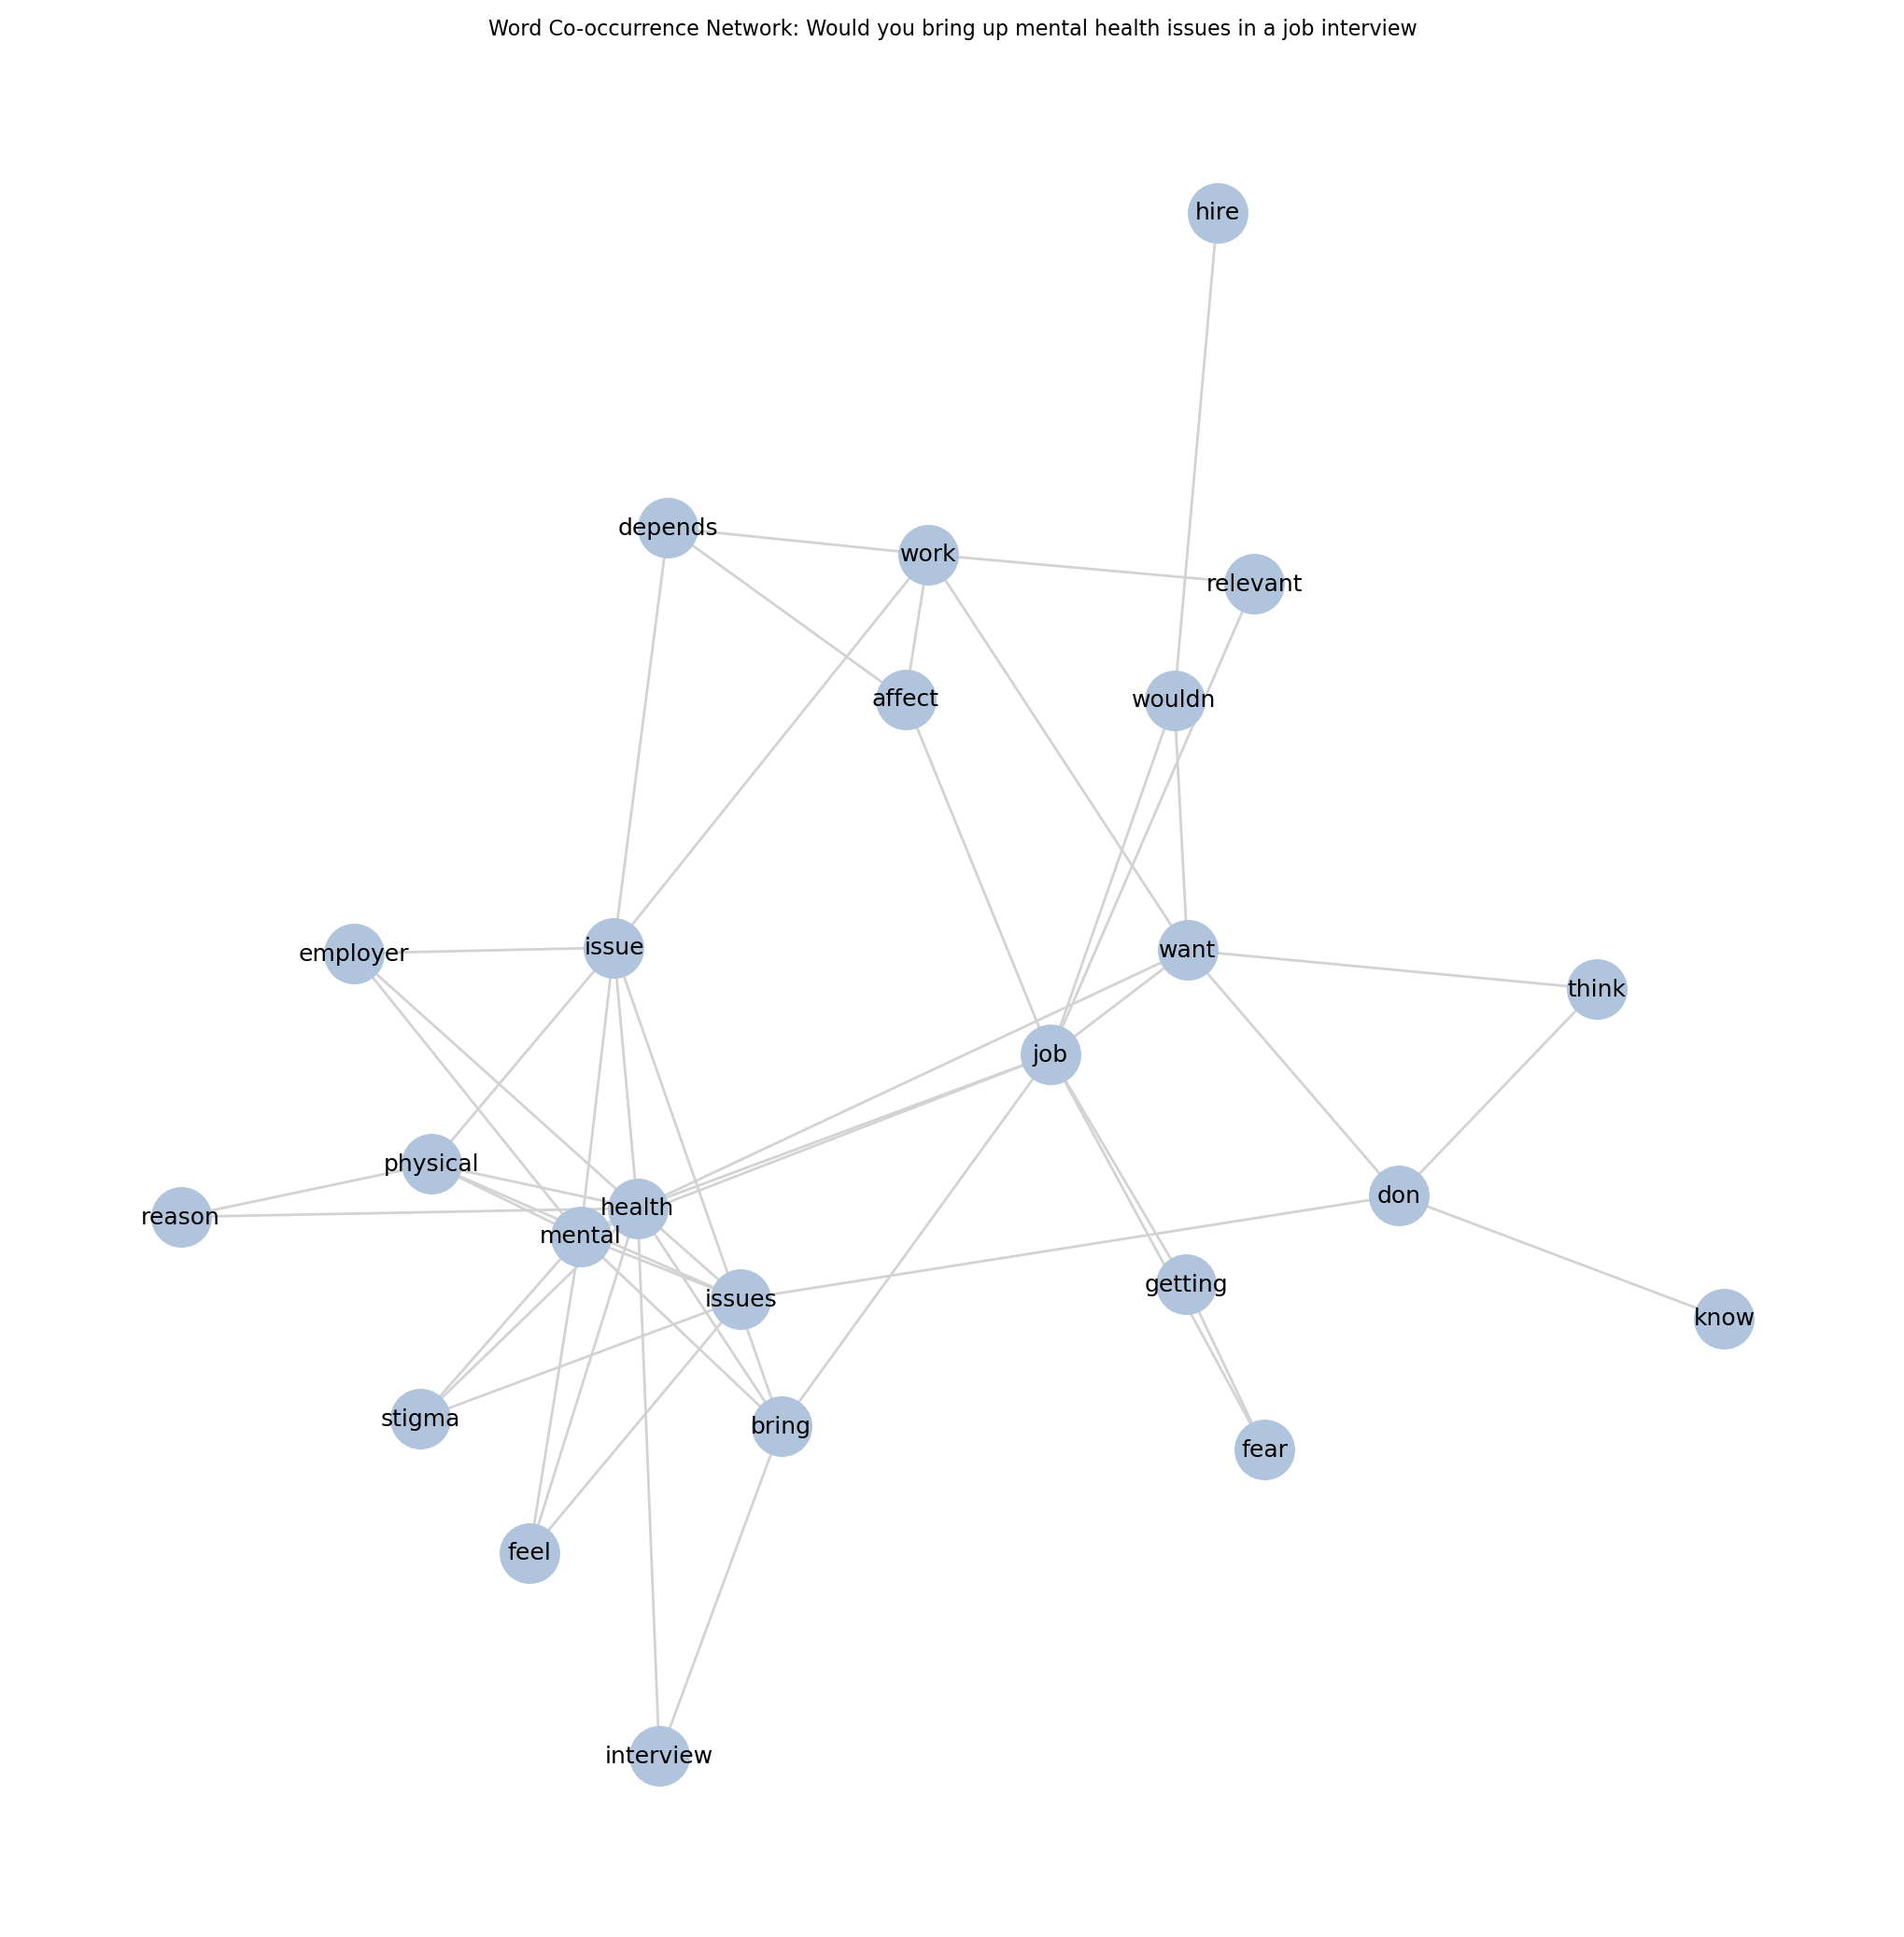

In [15]:
q40uni_cm = (q40uni[q40uni.iloc[:,:-1].sum().sort_values(ascending = False).head(25).index].T @ 
                       q40uni[q40uni.iloc[:,:-1].sum().sort_values(ascending = False).head(25).index])

G = nx.Graph()
for word1, word2 in q40uni_cm.stack().index:
    if word1 != word2 and q40uni_cm.loc[word1, word2] > np.quantile(np.array(q40uni_cm).flatten(), 0.8):  # Adjust threshold
        G.add_edge(word1, word2, weight=q40uni_cm.loc[word1, word2])

# Plot the network
plt.figure(figsize=(10, 10))
nx.draw(G, with_labels=True, node_size=500, node_color = 'lightsteelblue', edge_color='lightgray', font_size=9)
plt.title("Word Co-occurrence Network: Would you bring up mental health issues in a job interview")
plt.show()

#### 3. LDA for topic modelling

In [17]:
def get_top_words(model, feature_names, n_top_words=10):
    words = []
    for topic_idx, topic in enumerate(model.components_):
        words.append(" ".join([feature_names[i] for i in topic.argsort()[-n_top_words:][::-1]]))
        
    return words

In [18]:
lda = LatentDirichletAllocation(n_components=5, random_state=113)
topics = lda.fit_transform(q40uni.drop([c for c in q40uni.columns if c == 'cluster'],
                                       axis = 1).loc[responses[responses['Q39']==0].index])
words_respondents = {}
words = get_top_words(lda, q40uni.columns[:-1])
for i in range(topics.shape[1]):
    words_respondents[words[i]] = sum(topics.argmax(axis = 1)==i)

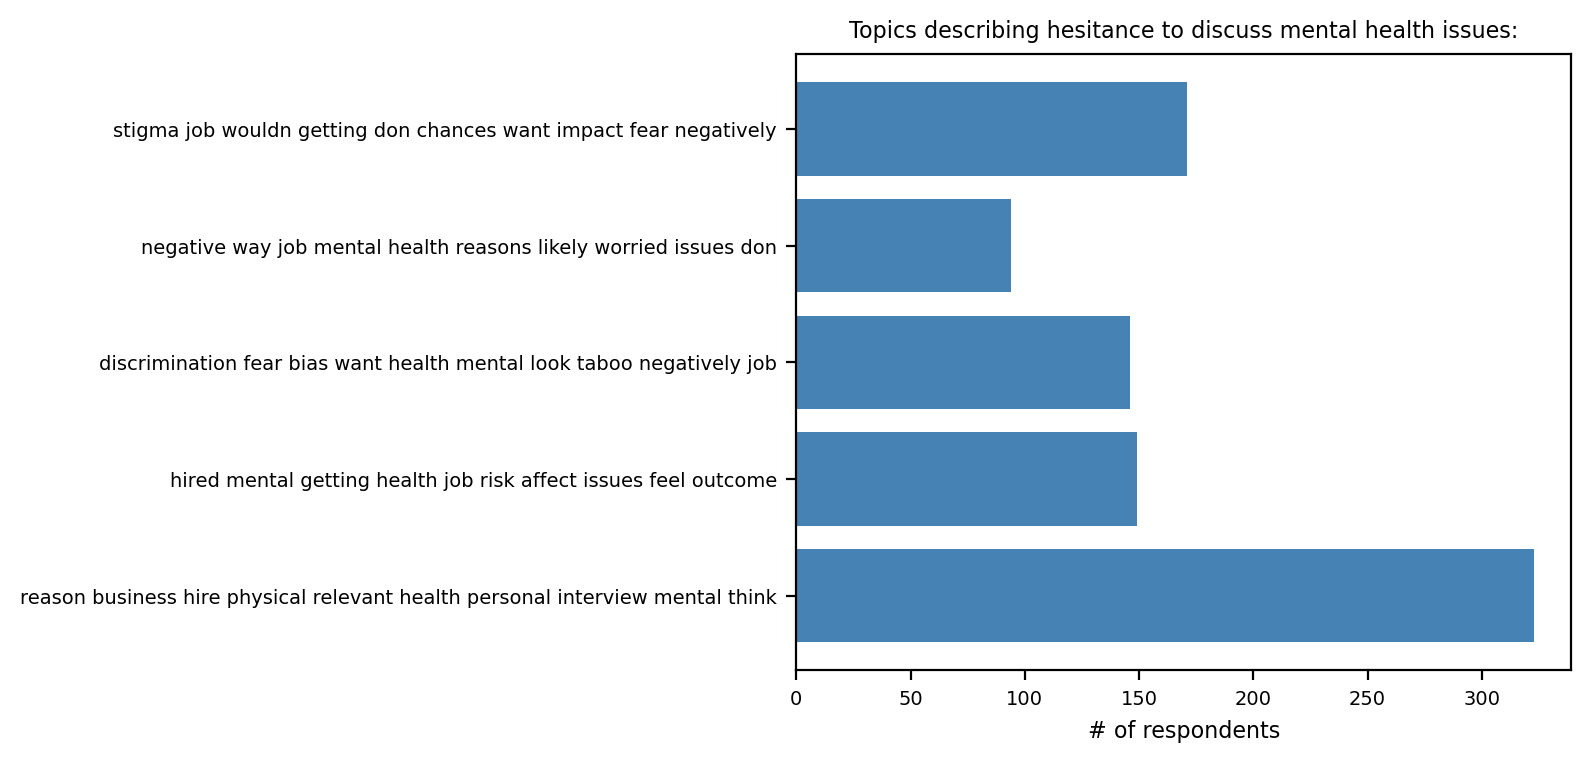

In [19]:
plt.barh(y = range(topics.shape[1]), width = words_respondents.values(), color = 'steelblue')
plt.yticks(range(topics.shape[1]), words_respondents.keys())
plt.title('Topics describing hesitance to discuss mental health issues:')
plt.xlabel('# of respondents')
plt.ylabel('');

In [20]:
lda = LatentDirichletAllocation(n_components=5, random_state=113)
topics = lda.fit_transform(q38uni.drop([c for c in q38uni.columns if c == 'cluster'],
                                       axis = 1).loc[responses[responses['Q37']==0].index])
words_respondents = {}
words = get_top_words(lda, q38uni.columns[:-1])
for i in range(topics.shape[1]):
    words_respondents[words[i]] = sum(topics.argmax(axis = 1)==i)

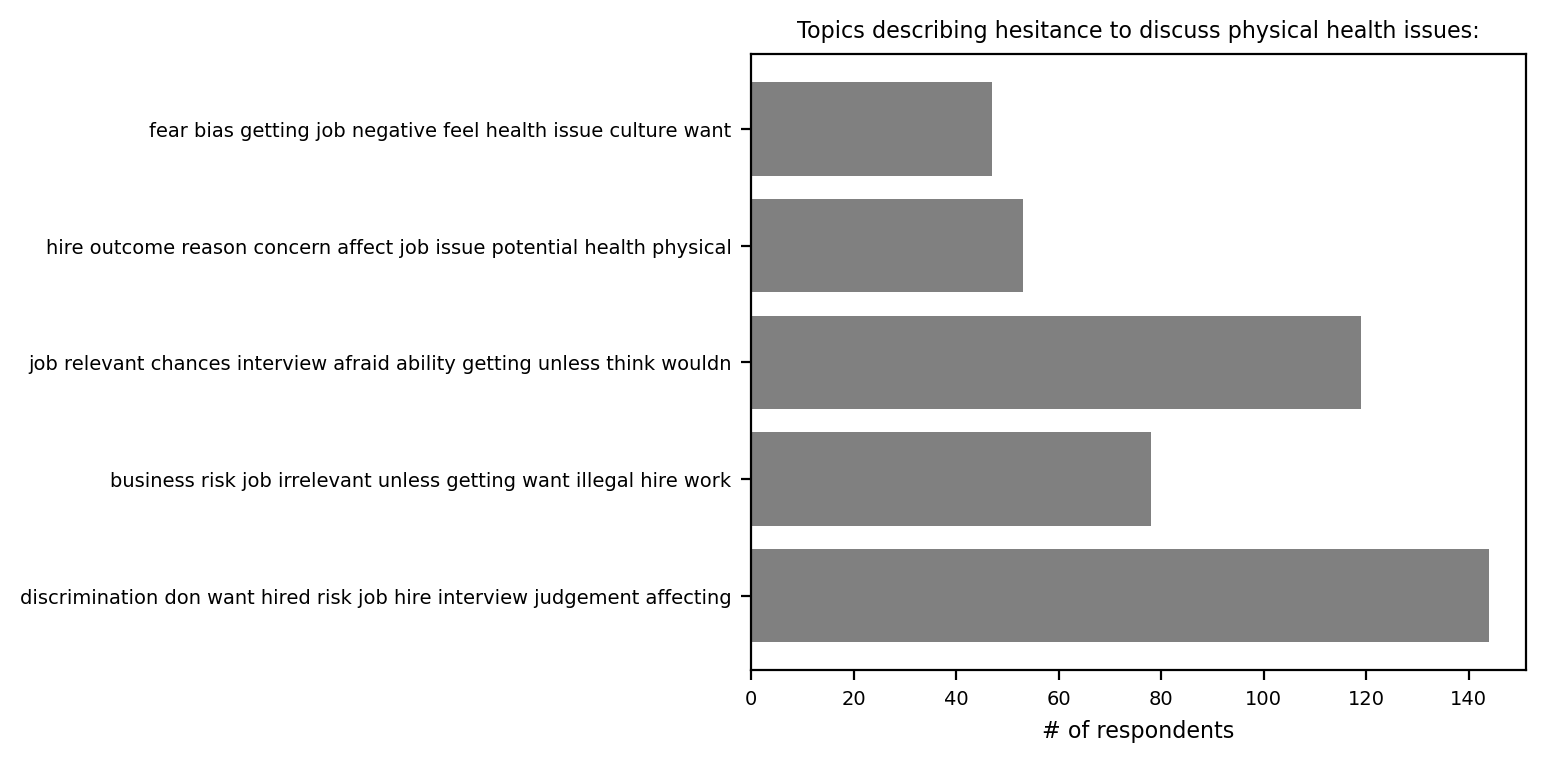

In [21]:
plt.barh(y = range(topics.shape[1]), width = words_respondents.values(), color = 'gray')
plt.yticks(range(topics.shape[1]), words_respondents.keys())
plt.title('Topics describing hesitance to discuss physical health issues:')
plt.xlabel('# of respondents')
plt.ylabel('');

#### 4. Sentiment analysis

In [22]:
sia = SentimentIntensityAnalyzer()
sia_scores = responses[[f'Q{q}' for q in range(37, 41)]]
for q in ['Q38', 'Q40']:
    sia_scores.loc[:, f"sia{q}"] = sia_scores[q].apply(lambda x: sia.polarity_scores(str(x))['compound'])

/var/folders/s5/1c98d9r93rg6lzxgmf01jj0m0000gn/T/ipykernel_61602/3785672222.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sia_scores.loc[:, f"sia{q}"] = sia_scores[q].apply(lambda x: sia.polarity_scores(str(x))['compound'])
/var/folders/s5/1c98d9r93rg6lzxgmf01jj0m0000gn/T/ipykernel_61602/3785672222.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sia_scores.loc[:, f"sia{q}"] = sia_scores[q].apply(lambda x: sia.polarity_scores(str(x))['compound'])


In [23]:
pd.set_option('display.max_colwidth', None)

In [24]:
sia_scores.dropna().sample(3)

,Q37,Q38,Q39,Q40,siaQ38,siaQ40
rid,,,,,,
2d946ab6-eb0b-4f0c-97d8-ca8dab267d8c,0.5,Only would do it if I would believe it would have impact on my productivity.,0.0,Not sure how the employer would see the problem there's no information available for them or on the mental problems and how to deal with it.,0.0000,-0.8206
22d783fe-3954-4ea9-b0bb-58acccf8b09d,0.5,Fear of being passed over for a healthier candidate.,0.0,Fear that it would disqualify me in their mind.,-0.4939,-0.4939
cae1f2e4-80fc-44db-81f2-e6cbb9058bde,0.5,"Dependant on how comfortable I felt speaking the interviewer(s), dependant if they have mentioned there is an avenue/approach they embrace to address physical health issues.",0.5,"Dependant on how comfortable I felt speaking the interviewer(s), dependant if they have mentioned there is an avenue/approach they embrace to address mental health issues. Dependant on how my mental health is that day/week/ etc",0.6808,0.6808


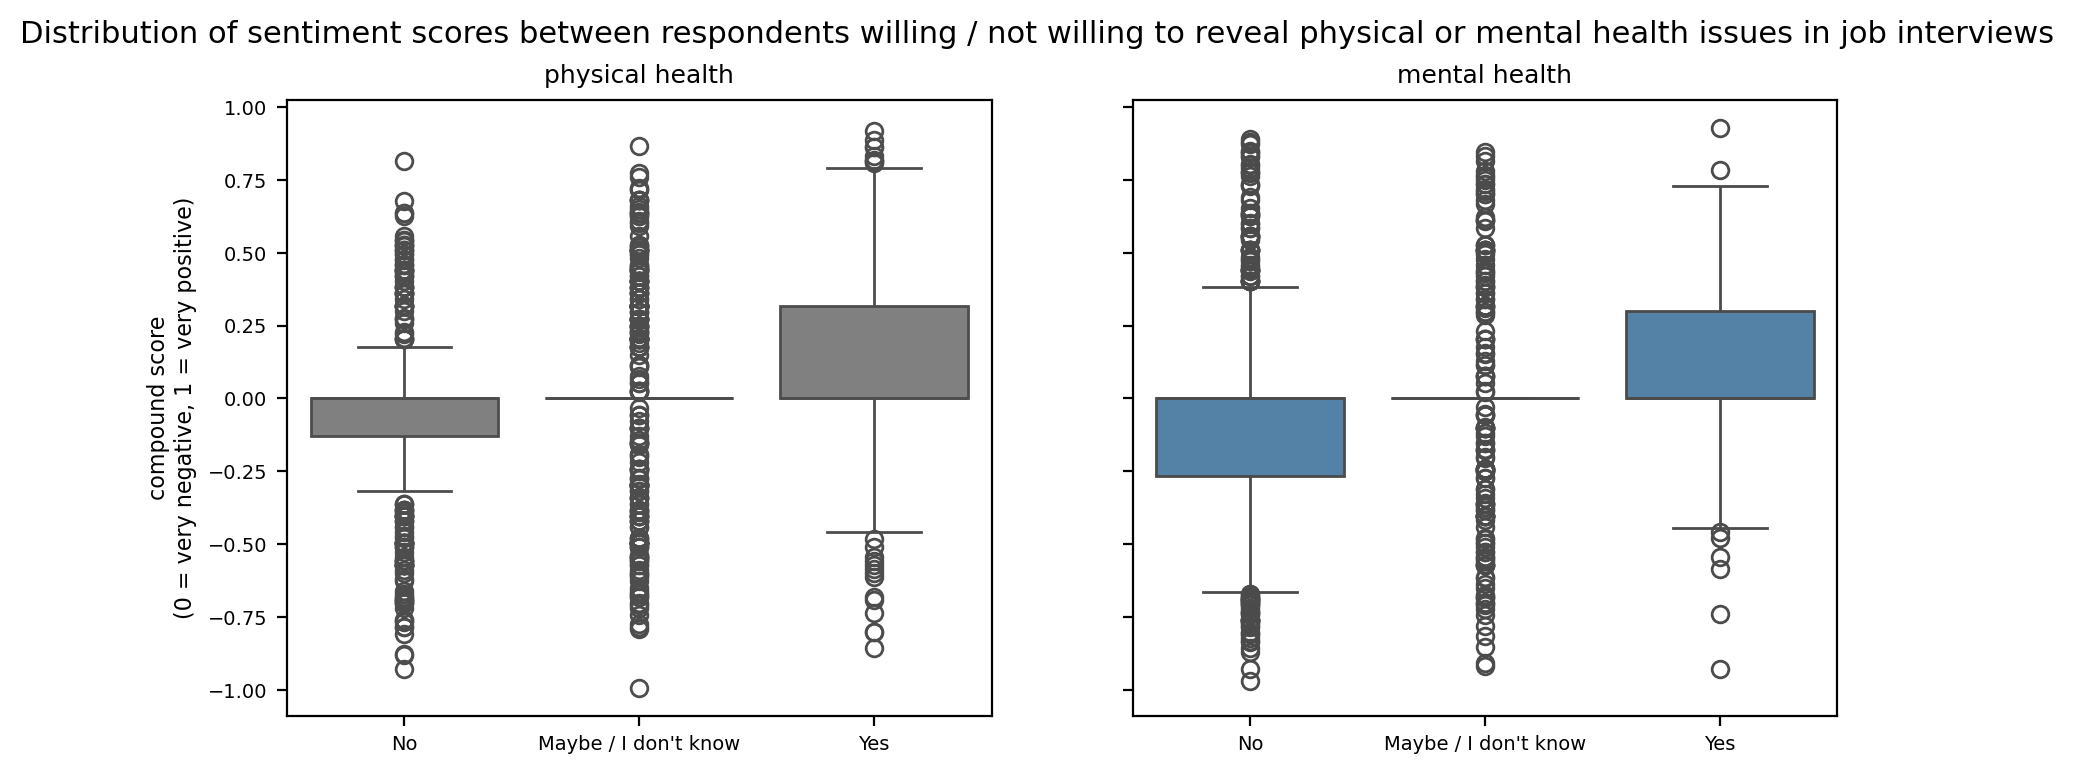

In [25]:
fig, axs = plt.subplots(1,2, figsize = (10,4), sharey=True)
plt.suptitle('Distribution of sentiment scores between respondents willing / not willing to reveal physical or mental health issues in job interviews', fontsize = 11)
axs[0].set_title('physical health', fontsize = 9)
sns.boxplot(sia_scores, x = 'Q37', y = 'siaQ38', order=[0, 0.5, 1], color = 'gray', ax = axs[0]);
axs[0].set_xlabel('')
axs[0].set_xticks(range(3), ['No', 'Maybe / I don\'t know', 'Yes'])
axs[0].set_ylabel('compound score\n(0 = very negative, 1 = very positive)')
sns.boxplot(sia_scores, x = 'Q39', y = 'siaQ40', order=[0, 0.5, 1],  color = 'steelblue', ax = axs[1]);
axs[1].set_xlabel('')
axs[1].set_xticks(range(3), ['No', 'Maybe / I don\'t know', 'Yes'])
axs[1].set_title('mental health', fontsize = 9);

#### 5. PCA & clustering

In [26]:
expl_var_n = {'Q38': {'uni':{}, 'bi': {}}, 'Q40':  {'uni':{}, 'bi': {}}}

for n in range(25, 501, 50):
    pca = PCA(n_components=n)
    pca.fit_transform(q38uni)
    expl_var_n['Q38']['uni'][n] = pca.explained_variance_.sum()
    pca = PCA(n_components=n)
    pca.fit_transform(q38bi)
    expl_var_n['Q38']['bi'][n] = pca.explained_variance_.sum()
    pca = PCA(n_components=n)
    pca.fit_transform(q40uni)
    expl_var_n['Q40']['uni'][n] = pca.explained_variance_.sum()
    pca = PCA(n_components=n)
    pca.fit_transform(q40bi)
    expl_var_n['Q40']['bi'][n] = pca.explained_variance_.sum()

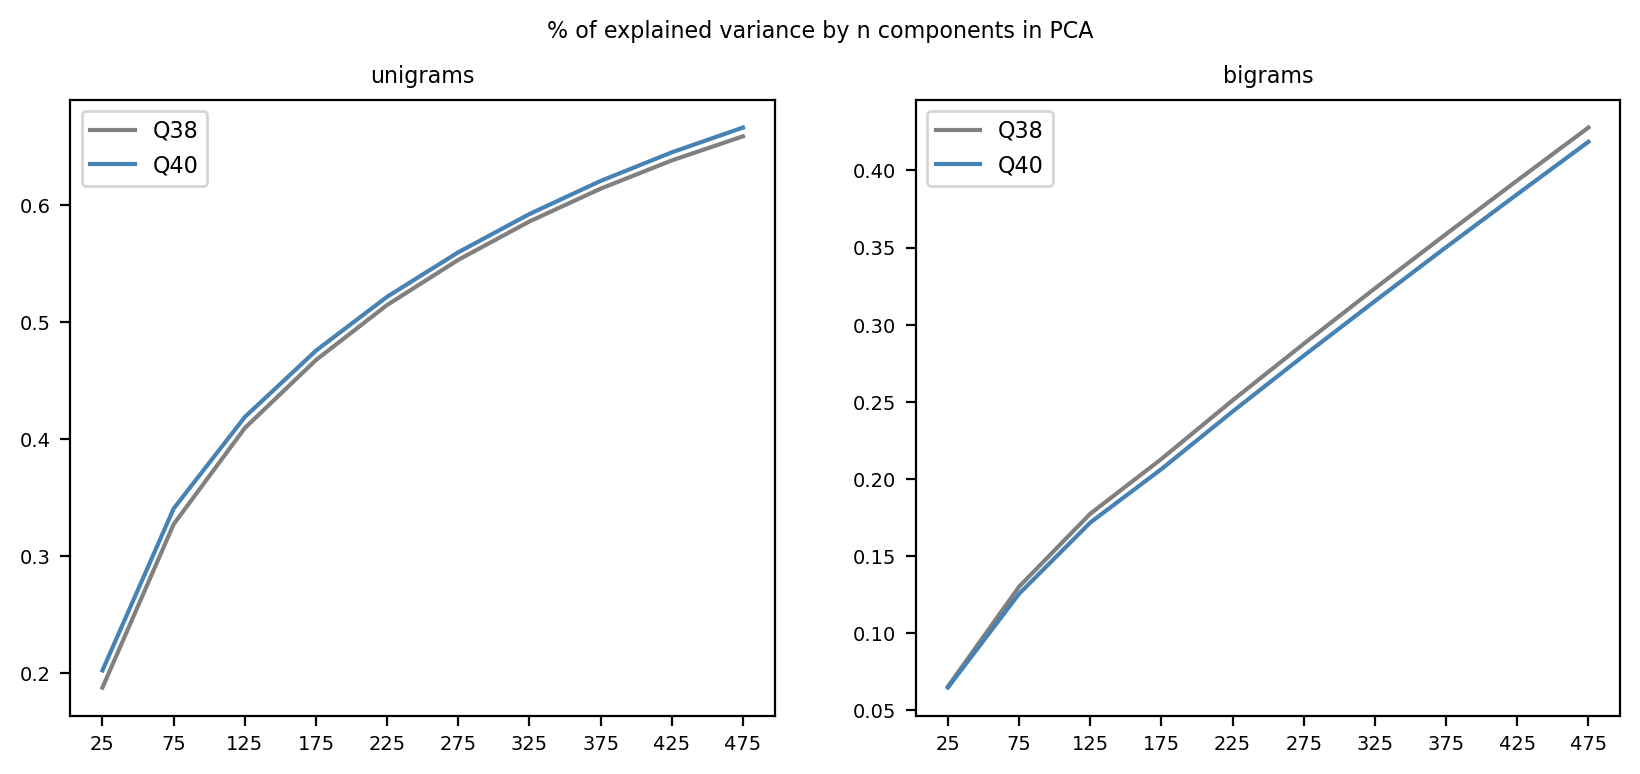

In [27]:
fig, axs = plt.subplots(1,2, figsize = (10,4))
plt.suptitle('% of explained variance by n components in PCA')
ubs = ['uni', 'bi']
for i in range(2):
    axs[i].plot(range(len(expl_var_n['Q38'][ubs[i]].keys())), expl_var_n['Q38'][ubs[i]].values(), color = 'gray', label = 'Q38')
    axs[i].plot(range(len(expl_var_n['Q40'][ubs[i]].keys())), expl_var_n['Q40'][ubs[i]].values(), color = 'steelblue', label = 'Q40');
    axs[i].set_title(f'{ubs[i]}grams')
    axs[i].set_xticks(range(len(expl_var_n['Q38'][ubs[i]].keys())))
    axs[i].set_xticklabels(expl_var_n['Q38'][ubs[i]].keys());
    axs[i].legend(fontsize = 8);

In [28]:
expl_var_n = {'Q38': {}, 'Q40': {}}

for n in range(25, 501, 50):
    pca = PCA(n_components=n)
    try:
        pca.fit_transform(q38uni.drop([c for c in q38uni.columns if c == 'cluster'], axis = 1).loc[responses[responses['Q37']==0].index])
        expl_var_n['Q38'][n] = pca.explained_variance_.sum()
    except:
        pass
    pca = PCA(n_components=n)
    try:
        pca.fit_transform(q40uni.drop([c for c in q40uni.columns if c == 'cluster'], axis = 1).loc[responses[responses['Q39']==0].index])
        expl_var_n['Q40'][n] = pca.explained_variance_.sum()
    except:
        pass

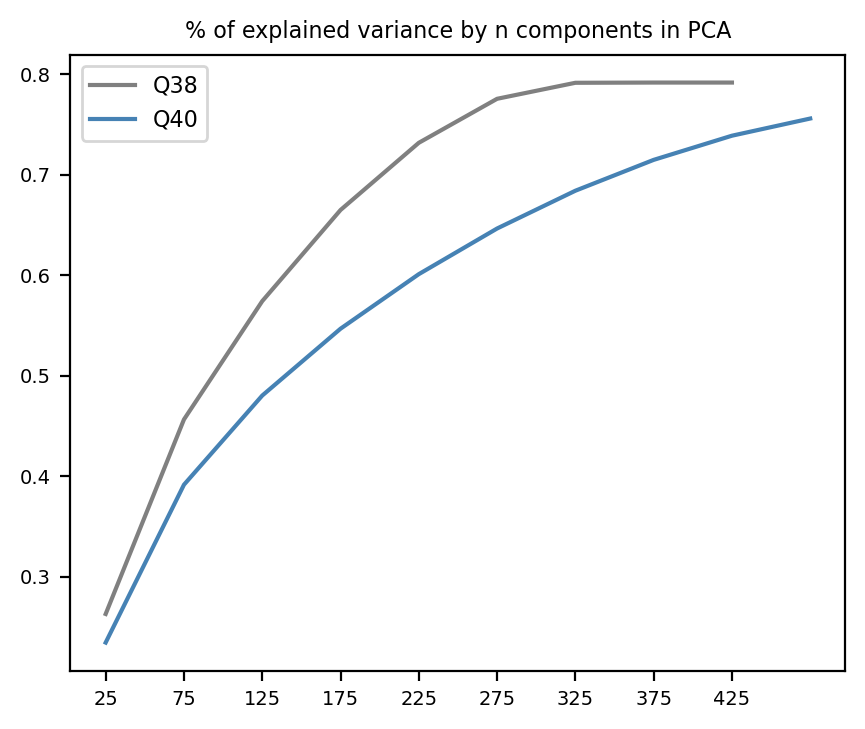

In [29]:
plt.title('% of explained variance by n components in PCA')
plt.plot(range(len(expl_var_n['Q38'].keys())), expl_var_n['Q38'].values(), color = 'gray', label = 'Q38')
plt.plot(range(len(expl_var_n['Q40'].keys())), expl_var_n['Q40'].values(), color = 'steelblue', label = 'Q40');
plt.xticks(range(len(expl_var_n['Q38'].keys())), expl_var_n['Q38'].keys());
plt.legend(fontsize = 8);

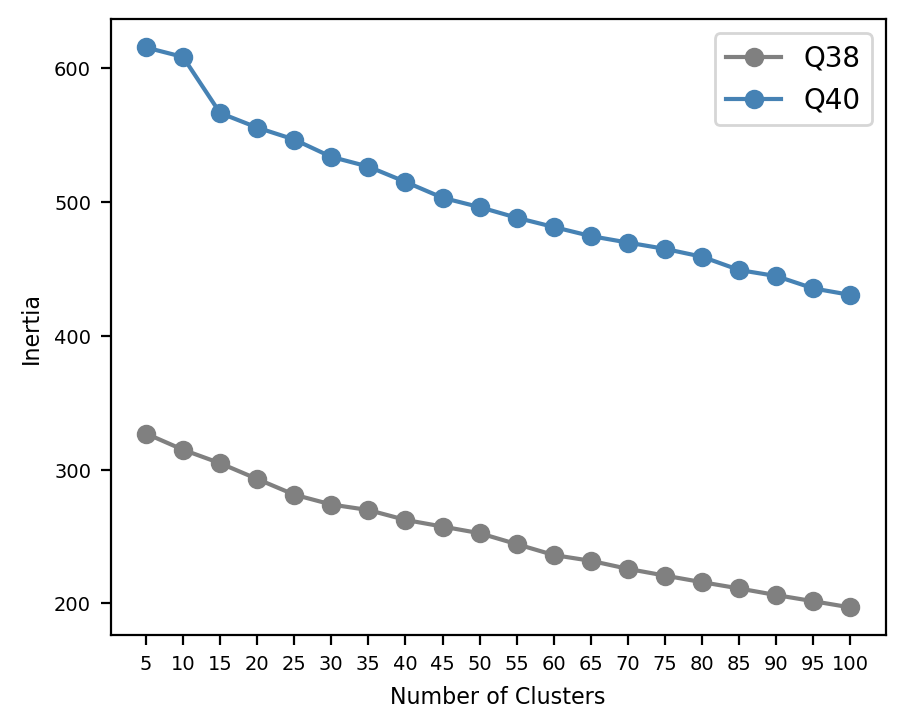

In [30]:
pca = PCA(n_components = 425)
q40pca = pca.fit_transform(q40uni.drop([c for c in q40uni.columns if c == 'cluster'],
                                       axis = 1).loc[responses[responses['Q39']==0].index])

pca = PCA(n_components = 275)
q38pca = pca.fit_transform(q38uni.drop([c for c in q38uni.columns if c == 'cluster'], 
                                       axis = 1).loc[responses[responses['Q37']==0].index])

inertia = {'Q38':[], 'Q40': []}
for k in range(5, 101,5):
    kmeans = KMeans(n_clusters=k, random_state=113)
    kmeans.fit(q40pca)
    inertia['Q40'].append(kmeans.inertia_)
    kmeans = KMeans(n_clusters=k, random_state=113)
    kmeans.fit(q38pca)
    inertia['Q38'].append(kmeans.inertia_)
plt.plot(range(5, 101,5), inertia['Q38'], color = 'gray', marker='o', label = 'Q38')
plt.plot(range(5, 101, 5), inertia['Q40'], color = 'steelblue', marker='o', label = 'Q40')
plt.xticks(range(5, 101,5), range(5, 101,5))
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.legend()
plt.show()

In [31]:
pca = PCA(n_components = 3, random_state=113)
pca_df = pd.DataFrame(data = pca.fit_transform(q38uni), index = q38uni.index, columns = ['PC1Q38', 'PC2Q38', 'PC3Q38'])

In [32]:
pca = PCA(n_components = 3, random_state=113)
pca_df = pca_df.merge(pd.DataFrame(data = pca.fit_transform(q40uni), index = q40uni.index, columns = ['PC1Q40', 'PC2Q40', 'PC3Q40']),
                     left_index = True, right_index = True)

In [33]:
us_responses = responses[responses.index.isin(demo[demo['Q60']=='United States of America'].index.unique())]
nonus_responses = responses[responses.index.isin(demo[demo['Q60']!='United States of America'].index.unique())]

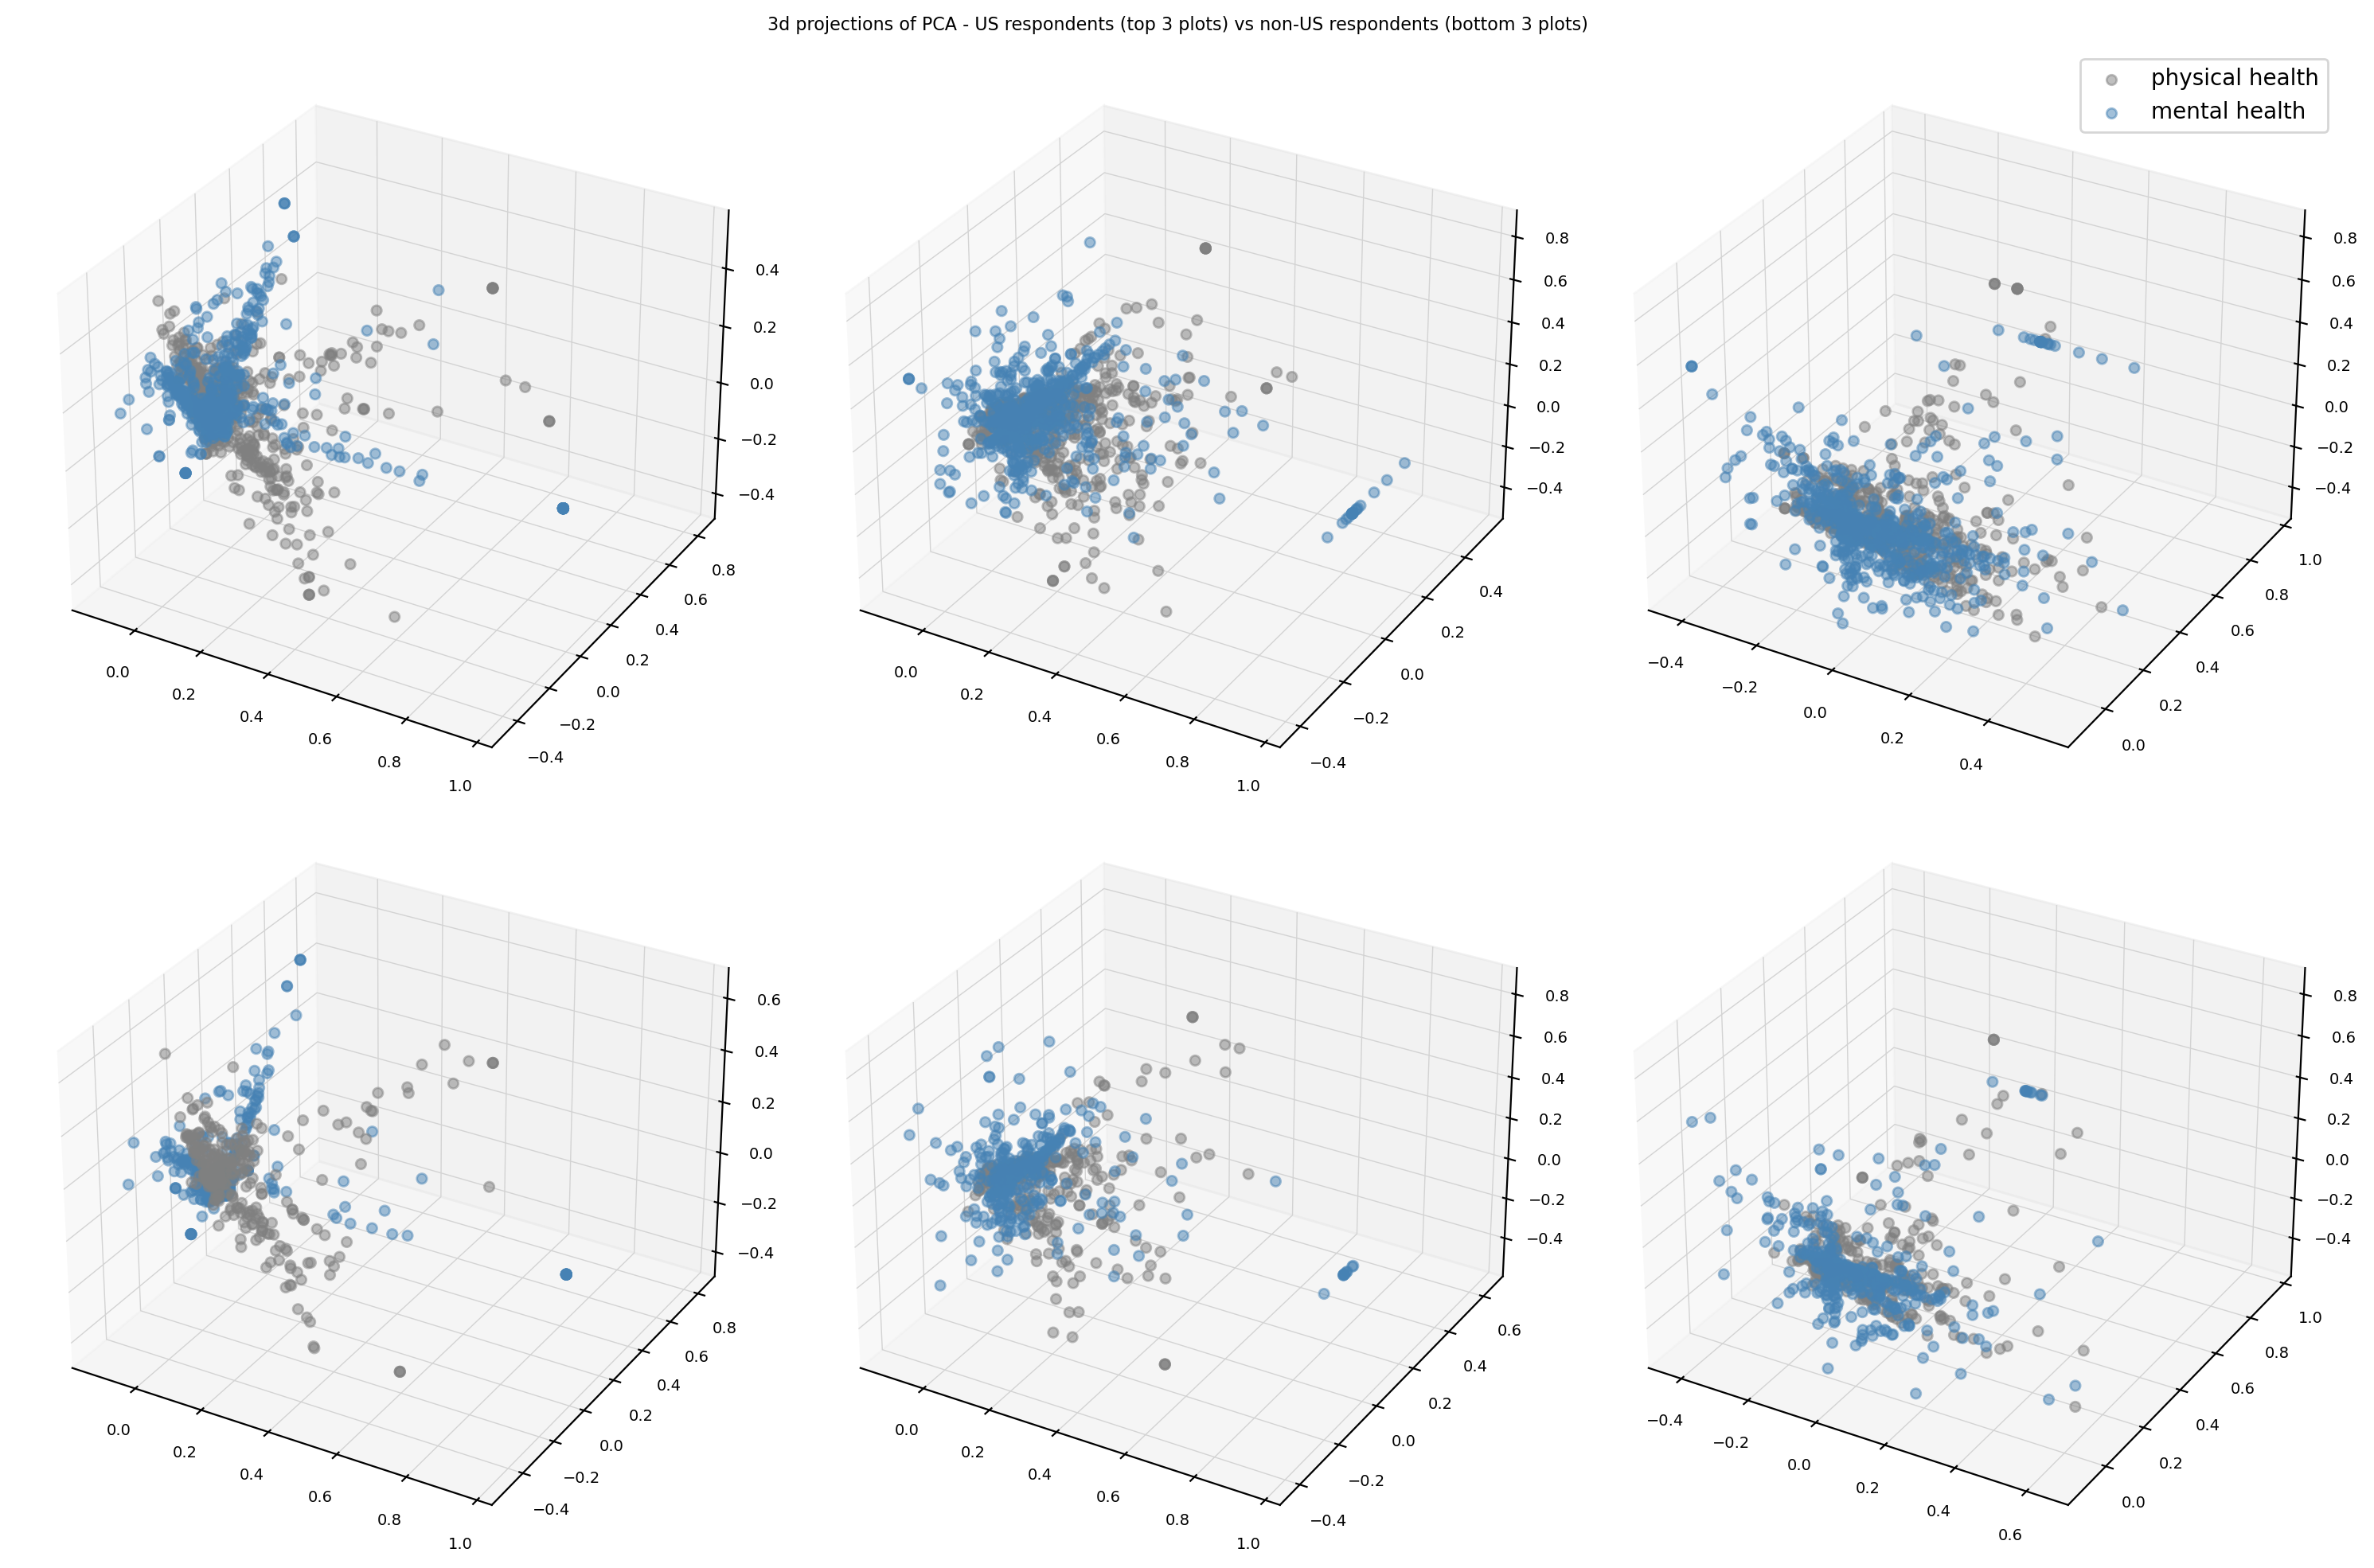

In [34]:
#fig, axs = plt.subplots(1, 2, figsize=(15, 6), )
fig = plt.figure(figsize=(15, 10))
pca_df1 = pca_df.loc[us_responses.index]
pca_df2 = pca_df.loc[nonus_responses.index]

axs00 = fig.add_subplot(2, 3, 1, projection='3d')
axs00.scatter(xs=pca_df1['PC1Q38'], ys=pca_df1['PC2Q38'], zs =pca_df1['PC3Q38'] , alpha=0.5, color = 'gray', label = 'physical health')
axs00.scatter(xs=pca_df1['PC1Q40'], ys=pca_df1['PC2Q40'], zs =pca_df1['PC3Q40'], alpha=0.5, color = 'steelblue', label = 'mental health')
axs01 = fig.add_subplot(2, 3, 2, projection='3d')
axs01.scatter(xs=pca_df1['PC1Q38'], zs=pca_df1['PC2Q38'], ys =pca_df1['PC3Q38'] ,alpha=0.5, color = 'gray', label = 'physical health')
axs01.scatter(xs=pca_df1['PC1Q40'], zs=pca_df1['PC2Q40'], ys =pca_df1['PC3Q38'] ,alpha=0.5, color = 'steelblue', label = 'mental health')
axs02 = fig.add_subplot(2, 3, 3, projection='3d')
axs02.scatter(ys=pca_df1['PC1Q38'], zs=pca_df1['PC2Q38'], xs =pca_df1['PC3Q38'] ,alpha=0.5, color = 'gray', label = 'physical health')
axs02.scatter(ys=pca_df1['PC1Q40'], zs=pca_df1['PC2Q40'], xs =pca_df1['PC3Q38'] ,alpha=0.5, color = 'steelblue', label = 'mental health')
plt.suptitle("PCA - US respondents")
axs02.legend()

axs10 = fig.add_subplot(2, 3, 4, projection='3d', )
axs10.scatter(xs=pca_df2['PC1Q38'], ys=pca_df2['PC2Q38'], zs =pca_df2['PC3Q38'] , alpha=0.5, color = 'gray', label = 'physical health')
axs10.scatter(xs=pca_df2['PC1Q40'], ys=pca_df2['PC2Q40'], zs =pca_df2['PC3Q40'], alpha=0.5, color = 'steelblue', label = 'mental health')
axs11 = fig.add_subplot(2, 3, 5, projection='3d')
axs11.scatter(xs=pca_df2['PC1Q38'], zs=pca_df2['PC2Q38'], ys =pca_df2['PC3Q38'] ,alpha=0.5, color = 'gray', label = 'physical health')
axs11.scatter(xs=pca_df2['PC1Q40'], zs=pca_df2['PC2Q40'], ys =pca_df2['PC3Q38'] ,alpha=0.5, color = 'steelblue', label = 'mental health')
axs12 = fig.add_subplot(2, 3, 6, projection='3d')
axs12.scatter(ys=pca_df2['PC1Q38'], zs=pca_df2['PC2Q38'], xs =pca_df2['PC3Q38'] ,alpha=0.5, color = 'gray', label = 'physical health')
axs12.scatter(ys=pca_df2['PC1Q40'], zs=pca_df2['PC2Q40'], xs =pca_df2['PC3Q38'] ,alpha=0.5, color = 'steelblue', label = 'mental health')
plt.suptitle("3d projections of PCA - US respondents (top 3 plots) vs non-US respondents (bottom 3 plots)")
plt.tight_layout()
plt.show()